<a href="https://colab.research.google.com/github/IvanMalkS/ames-housing-predictions/blob/master/Ames.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [146]:
# IMPORTANT: SOME KAGGLE DATA SOURCES ARE PRIVATE
# RUN THIS CELL IN ORDER TO IMPORT YOUR KAGGLE DATA SOURCES.
import kagglehub
kagglehub.login()


In [147]:
# IMPORTANT: RUN THIS CELL IN ORDER TO IMPORT YOUR KAGGLE DATA SOURCES,
# THEN FEEL FREE TO DELETE THIS CELL.
# NOTE: THIS NOTEBOOK ENVIRONMENT DIFFERS FROM KAGGLE'S PYTHON
# ENVIRONMENT SO THERE MAY BE MISSING LIBRARIES USED BY YOUR
# NOTEBOOK.

house_prices_advanced_regression_techniques_path = kagglehub.competition_download('house-prices-advanced-regression-techniques')

print('Data source import complete.')


Data source import complete.


# Boston prices reserch

## Blocks

1) Exploration Data Analysis (EDA)
2) Data processing
3) Models treining
4) Feature engeneering
5) Ansamble models
6) Results

In [148]:
# catboost, xgboost, lightgbm — installed in conda env "ames"

In [149]:
import warnings
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

import torch
import torch.nn as nn
import torch.optim as optim

from sklearn.pipeline import Pipeline, make_pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler, OneHotEncoder, OrdinalEncoder
from sklearn.compose import ColumnTransformer
from sklearn.model_selection import train_test_split, GridSearchCV, StratifiedKFold, RandomizedSearchCV, cross_val_score, ShuffleSplit
from sklearn.metrics import accuracy_score, mean_squared_error, make_scorer, mean_absolute_percentage_error

from sklearn.linear_model import Lasso, Ridge, ElasticNet, LinearRegression
from sklearn.neighbors import KNeighborsRegressor
from sklearn.svm import SVR
from sklearn.tree import DecisionTreeRegressor

from sklearn.ensemble import RandomForestRegressor, VotingRegressor, StackingRegressor

from catboost import CatBoostRegressor
from xgboost import XGBRegressor
from lightgbm import LGBMRegressor

In [150]:
device = 'cuda' if torch.cuda.is_available() else 'cpu'

## EDA


### Data load

In [151]:
Train = pd.read_csv(house_prices_advanced_regression_techniques_path + '/train.csv')
Test = pd.read_csv(house_prices_advanced_regression_techniques_path + '/test.csv')

In [152]:
print(Train.shape)

Train.head(5)

(1460, 81)


,Id,MSSubClass,MSZoning,LotFrontage,LotArea,Street,Alley,LotShape,LandContour,Utilities,...,PoolArea,PoolQC,Fence,MiscFeature,MiscVal,MoSold,YrSold,SaleType,SaleCondition,SalePrice
0,1,60,RL,65.0,8450,Pave,NaN,Reg,Lvl,AllPub,...,0,NaN,NaN,NaN,0,2,2008,WD,Normal,208500
1,2,20,RL,80.0,9600,Pave,NaN,Reg,Lvl,AllPub,...,0,NaN,NaN,NaN,0,5,2007,WD,Normal,181500
2,3,60,RL,68.0,11250,Pave,NaN,IR1,Lvl,AllPub,...,0,NaN,NaN,NaN,0,9,2008,WD,Normal,223500
3,4,70,RL,60.0,9550,Pave,NaN,IR1,Lvl,AllPub,...,0,NaN,NaN,NaN,0,2,2006,WD,Abnorml,140000
4,5,60,RL,84.0,14260,Pave,NaN,IR1,Lvl,AllPub,...,0,NaN,NaN,NaN,0,12,2008,WD,Normal,250000


In [153]:
print(Test.shape)

Test.head(5)

(1459, 80)


,Id,MSSubClass,MSZoning,LotFrontage,LotArea,Street,Alley,LotShape,LandContour,Utilities,...,ScreenPorch,PoolArea,PoolQC,Fence,MiscFeature,MiscVal,MoSold,YrSold,SaleType,SaleCondition
0,1461,20,RH,80.0,11622,Pave,NaN,Reg,Lvl,AllPub,...,120,0,NaN,MnPrv,NaN,0,6,2010,WD,Normal
1,1462,20,RL,81.0,14267,Pave,NaN,IR1,Lvl,AllPub,...,0,0,NaN,NaN,Gar2,12500,6,2010,WD,Normal
2,1463,60,RL,74.0,13830,Pave,NaN,IR1,Lvl,AllPub,...,0,0,NaN,MnPrv,NaN,0,3,2010,WD,Normal
3,1464,60,RL,78.0,9978,Pave,NaN,IR1,Lvl,AllPub,...,0,0,NaN,NaN,NaN,0,6,2010,WD,Normal
4,1465,120,RL,43.0,5005,Pave,NaN,IR1,HLS,AllPub,...,144,0,NaN,NaN,NaN,0,1,2010,WD,Normal


On the date we could see a lot of `NaN` valuse, that we should replace by mean values

In [154]:
Train.info()

<class 'pandas.DataFrame'>
RangeIndex: 1460 entries, 0 to 1459
Data columns (total 81 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   Id             1460 non-null   int64  
 1   MSSubClass     1460 non-null   int64  
 2   MSZoning       1460 non-null   str    
 3   LotFrontage    1201 non-null   float64
 4   LotArea        1460 non-null   int64  
 5   Street         1460 non-null   str    
 6   Alley          91 non-null     str    
 7   LotShape       1460 non-null   str    
 8   LandContour    1460 non-null   str    
 9   Utilities      1460 non-null   str    
 10  LotConfig      1460 non-null   str    
 11  LandSlope      1460 non-null   str    
 12  Neighborhood   1460 non-null   str    
 13  Condition1     1460 non-null   str    
 14  Condition2     1460 non-null   str    
 15  BldgType       1460 non-null   str    
 16  HouseStyle     1460 non-null   str    
 17  OverallQual    1460 non-null   int64  
 18  OverallCond    1460

In [155]:
Train.columns.values

<StringArray>
[           'Id',    'MSSubClass',      'MSZoning',   'LotFrontage',
       'LotArea',        'Street',         'Alley',      'LotShape',
   'LandContour',     'Utilities',     'LotConfig',     'LandSlope',
  'Neighborhood',    'Condition1',    'Condition2',      'BldgType',
    'HouseStyle',   'OverallQual',   'OverallCond',     'YearBuilt',
  'YearRemodAdd',     'RoofStyle',      'RoofMatl',   'Exterior1st',
   'Exterior2nd',    'MasVnrType',    'MasVnrArea',     'ExterQual',
     'ExterCond',    'Foundation',      'BsmtQual',      'BsmtCond',
  'BsmtExposure',  'BsmtFinType1',    'BsmtFinSF1',  'BsmtFinType2',
    'BsmtFinSF2',     'BsmtUnfSF',   'TotalBsmtSF',       'Heating',
     'HeatingQC',    'CentralAir',    'Electrical',      '1stFlrSF',
      '2ndFlrSF',  'LowQualFinSF',     'GrLivArea',  'BsmtFullBath',
  'BsmtHalfBath',      'FullBath',      'HalfBath',  'BedroomAbvGr',
  'KitchenAbvGr',   'KitchenQual',  'TotRmsAbvGrd',    'Functional',
    'Fireplaces',   

Let's divide x and y, where y is `SalePrice`

In [156]:
X = Train.drop(['SalePrice'], axis=1)
Y = Train['SalePrice']

### Data visualization



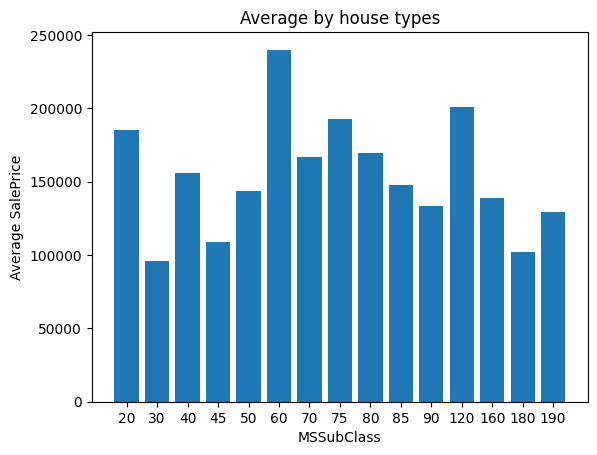

In [157]:
group_data = Train.groupby('MSSubClass')['SalePrice'].mean()

plt.bar(group_data.index.astype(str), group_data.values)
plt.xlabel('MSSubClass')
plt.ylabel('Average SalePrice')
plt.title('Average by house types')
plt.show()

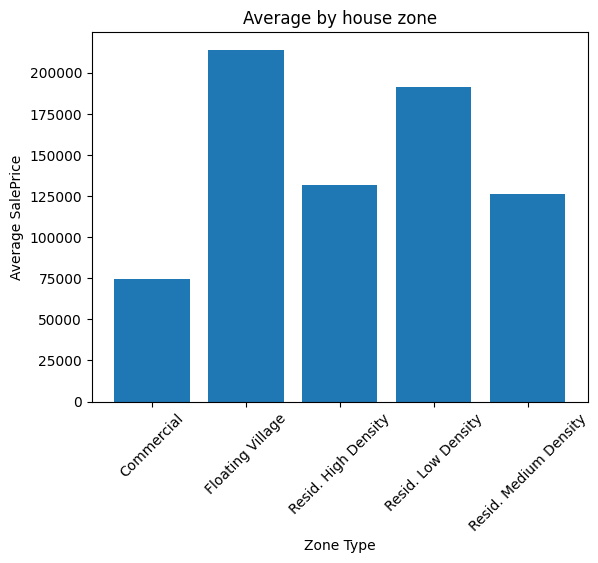

In [158]:
zoning_map = {
    'C (all)': 'Commercial',
    'FV': 'Floating Village',
    'RH': 'Resid. High Density',
    'RL': 'Resid. Low Density',
    'RM': 'Resid. Medium Density'
}

group_data = Train.groupby('MSZoning')['SalePrice'].mean()

plot_index = group_data.index.map(zoning_map)

plt.bar(plot_index, group_data.values)
plt.xlabel('Zone Type')
plt.ylabel('Average SalePrice')
plt.title('Average by house zone')
plt.xticks(rotation=45)
plt.show()

we can see that the most priced zone is floating vilages and low density zones

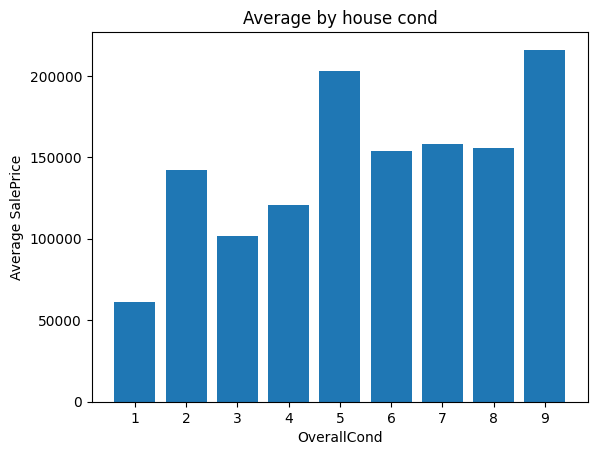

In [159]:
group_data = Train.groupby('OverallCond')['SalePrice'].mean()

plt.bar(group_data.index.astype(str), group_data.values)
plt.xlabel('OverallCond')
plt.ylabel('Average SalePrice')
plt.title('Average by house cond')
plt.show()

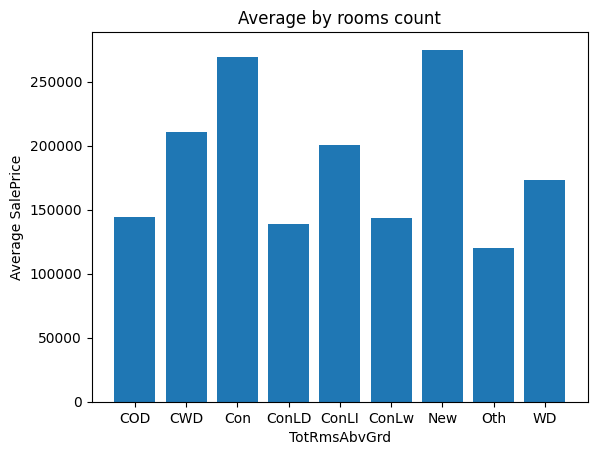

In [160]:
group_data = Train.groupby('SaleType')['SalePrice'].mean()

plt.bar(group_data.index.astype(str), group_data.values)
plt.xlabel('TotRmsAbvGrd')
plt.ylabel('Average SalePrice')
plt.title('Average by rooms count')
plt.show()

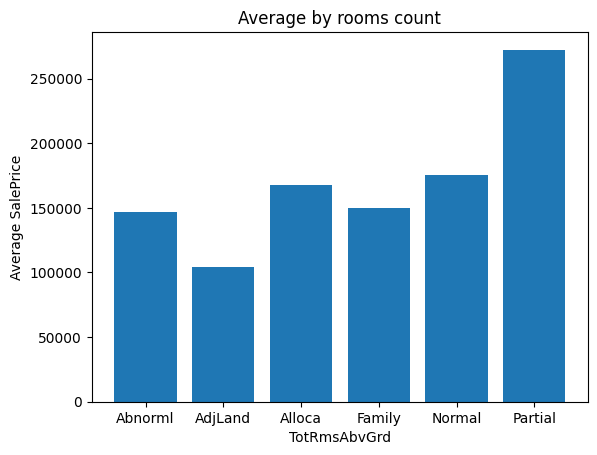

In [161]:
group_data = Train.groupby('SaleCondition')['SalePrice'].mean()

plt.bar(group_data.index.astype(str), group_data.values)
plt.xlabel('TotRmsAbvGrd')
plt.ylabel('Average SalePrice')
plt.title('Average by rooms count')
plt.show()

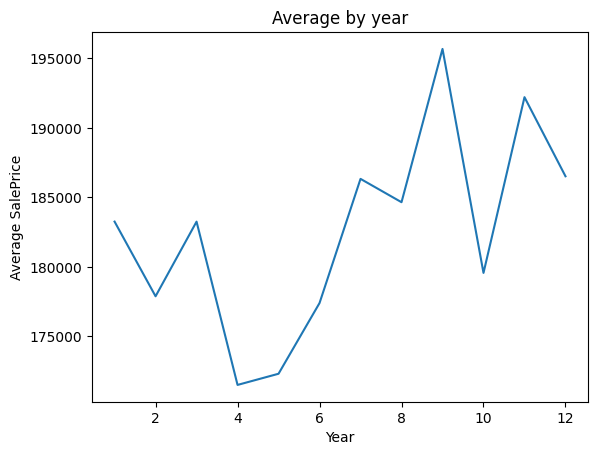

In [162]:
group_data = Train.groupby('MoSold')['SalePrice'].mean()

plt.plot(group_data.index, group_data.values)
plt.xlabel('Year')
plt.ylabel('Average SalePrice')
plt.title('Average by year')
plt.show()

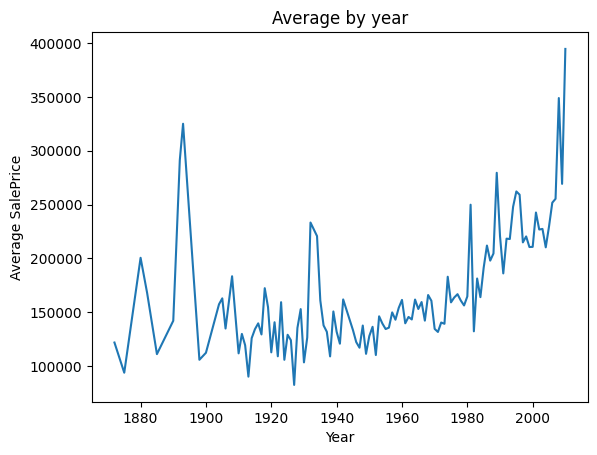

In [163]:
group_data = Train.groupby('YearBuilt')['SalePrice'].mean()

plt.plot(group_data.index, group_data.values)
plt.xlabel('Year')
plt.ylabel('Average SalePrice')
plt.title('Average by year')
plt.show()

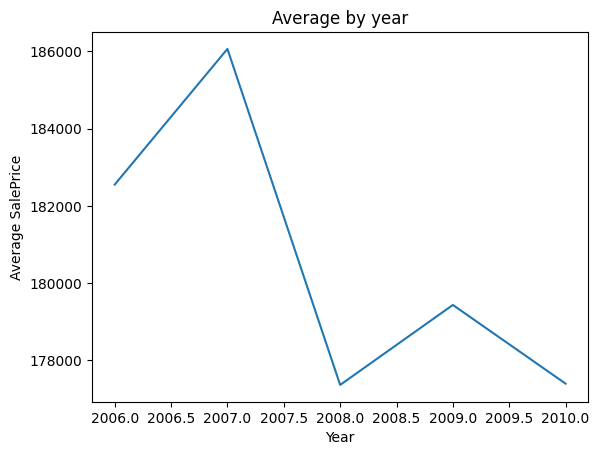

In [164]:
group_data = Train.groupby('YrSold')['SalePrice'].mean()

plt.plot(group_data.index, group_data.values)
plt.xlabel('Year')
plt.ylabel('Average SalePrice')
plt.title('Average by year')
plt.show()

We can see price falls in 2008 - 2010 and great growth in 2007

1) 2007 - The peak of the Mortgage crisis bubble
2) 2008 - The mortgage crisis
3) 2010 - The recession after the crash

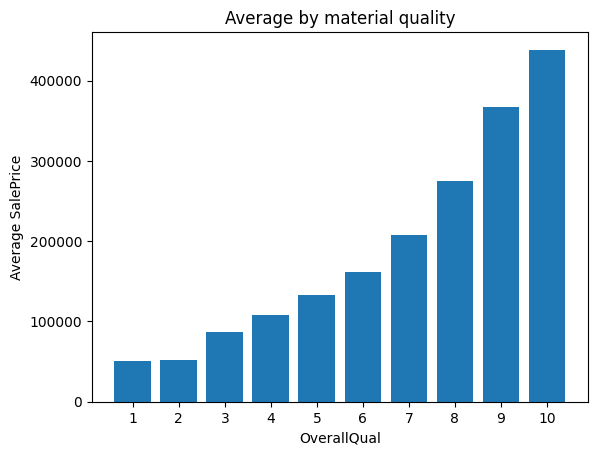

In [165]:
group_data = Train.groupby('OverallQual')['SalePrice'].mean()

plt.bar(group_data.index.astype(str), group_data.values)
plt.xlabel('OverallQual')
plt.ylabel('Average SalePrice')
plt.title('Average by material quality')
plt.show()

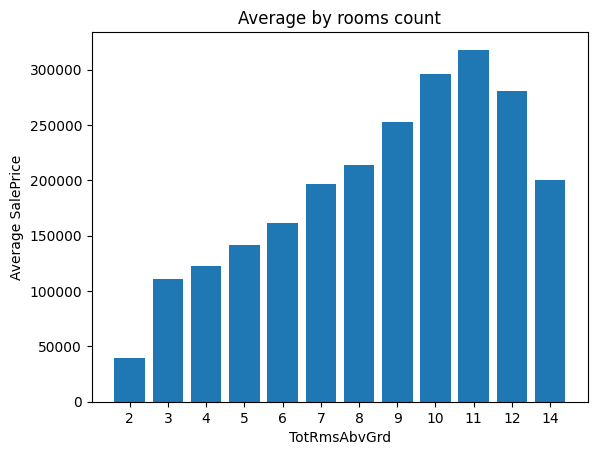

In [166]:
group_data = Train.groupby('TotRmsAbvGrd')['SalePrice'].mean()

plt.bar(group_data.index.astype(str), group_data.values)
plt.xlabel('TotRmsAbvGrd')
plt.ylabel('Average SalePrice')
plt.title('Average by rooms count')
plt.show()

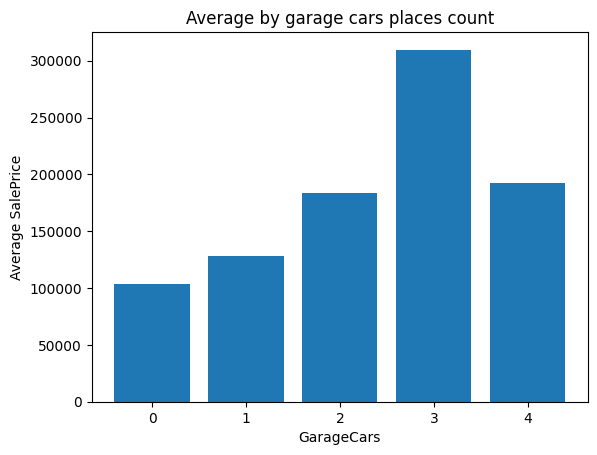

In [167]:
group_data = Train.groupby('GarageCars')['SalePrice'].mean()

plt.bar(group_data.index.astype(str), group_data.values)
plt.xlabel('GarageCars')
plt.ylabel('Average SalePrice')
plt.title('Average by garage cars places count')
plt.show()

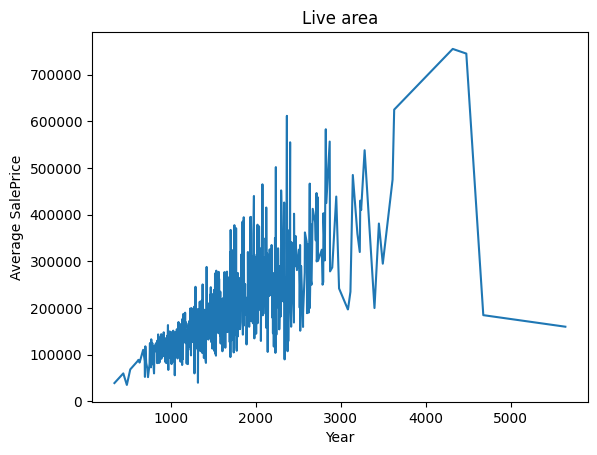

In [168]:
group_data = Train.groupby('GrLivArea')['SalePrice'].mean()

plt.plot(group_data.index, group_data.values)
plt.xlabel('Year')
plt.ylabel('Average SalePrice')
plt.title('Live area')
plt.show()

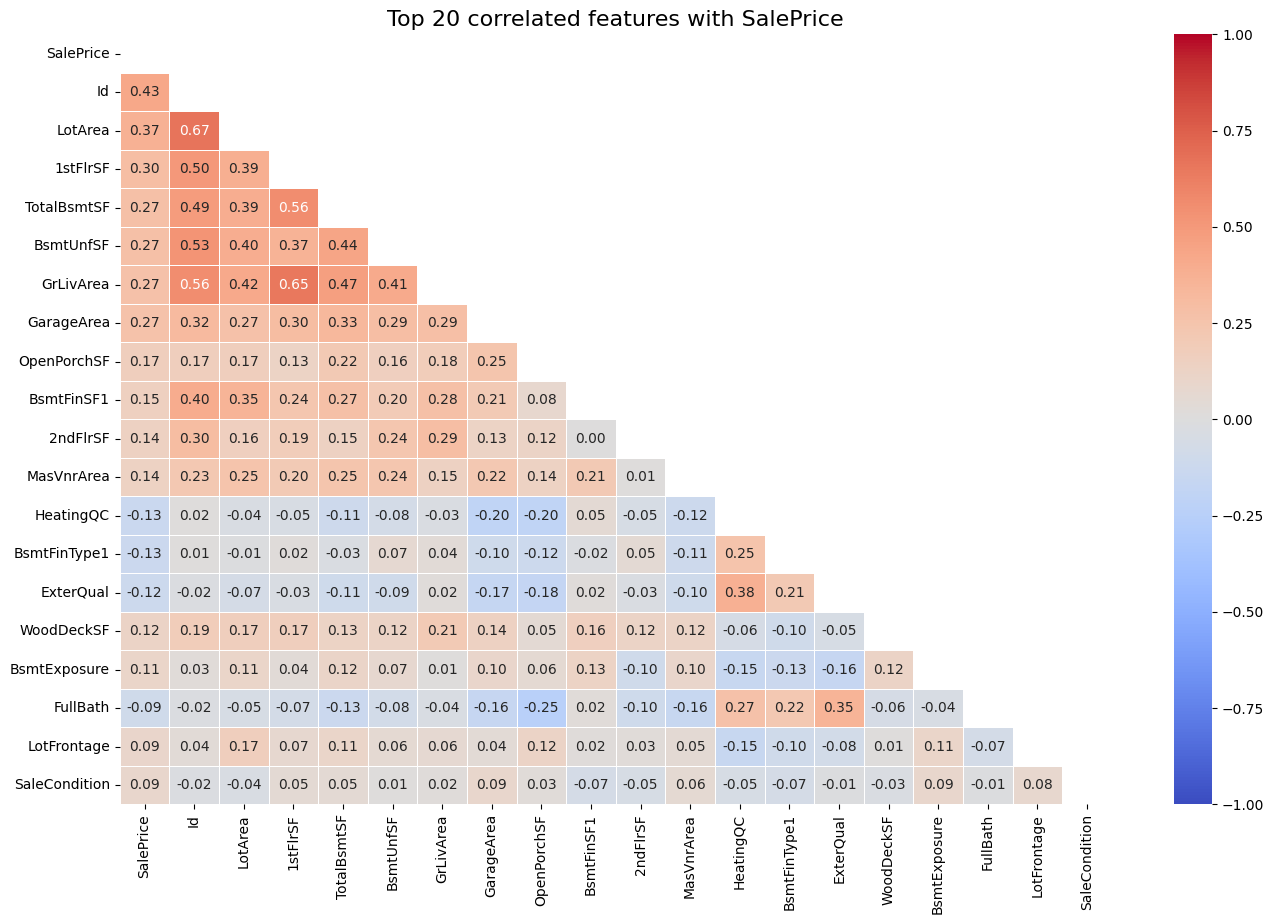

In [169]:
full_df = pd.concat([X, Y], axis=1)

df_encoded = full_df.apply(lambda x: pd.factorize(x)[0])

corr = df_encoded.corr()

top_20_features = corr['SalePrice'].abs().sort_values(ascending=False).head(20).index
top_corr = corr.loc[top_20_features, top_20_features]

plt.figure(figsize=(16, 10))

mask = np.triu(np.ones_like(top_corr, dtype=bool))

ax = sns.heatmap(
    top_corr,
    mask=mask,
    annot=True,
    fmt=".2f",
    linewidths=.5,
    cmap='coolwarm',
    vmin=-1,
    vmax=1
)

plt.title("Top 20 correlated features with SalePrice", fontsize=16)
plt.show()

By the **Average by material quality**  and **Average by rooms count** and **Average by garage cars places count** and **Live area** plot seems obvios correlations italicized text

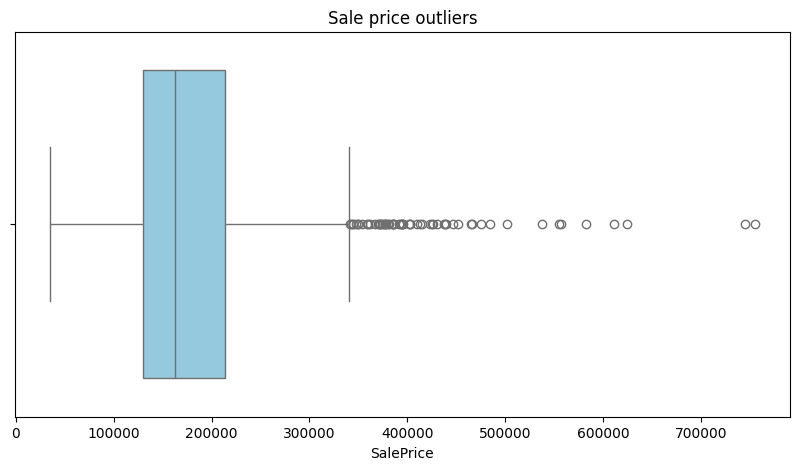

In [170]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(10, 5))
sns.boxplot(x=Train['SalePrice'], color='skyblue')
plt.title('Sale price outliers')
plt.show()

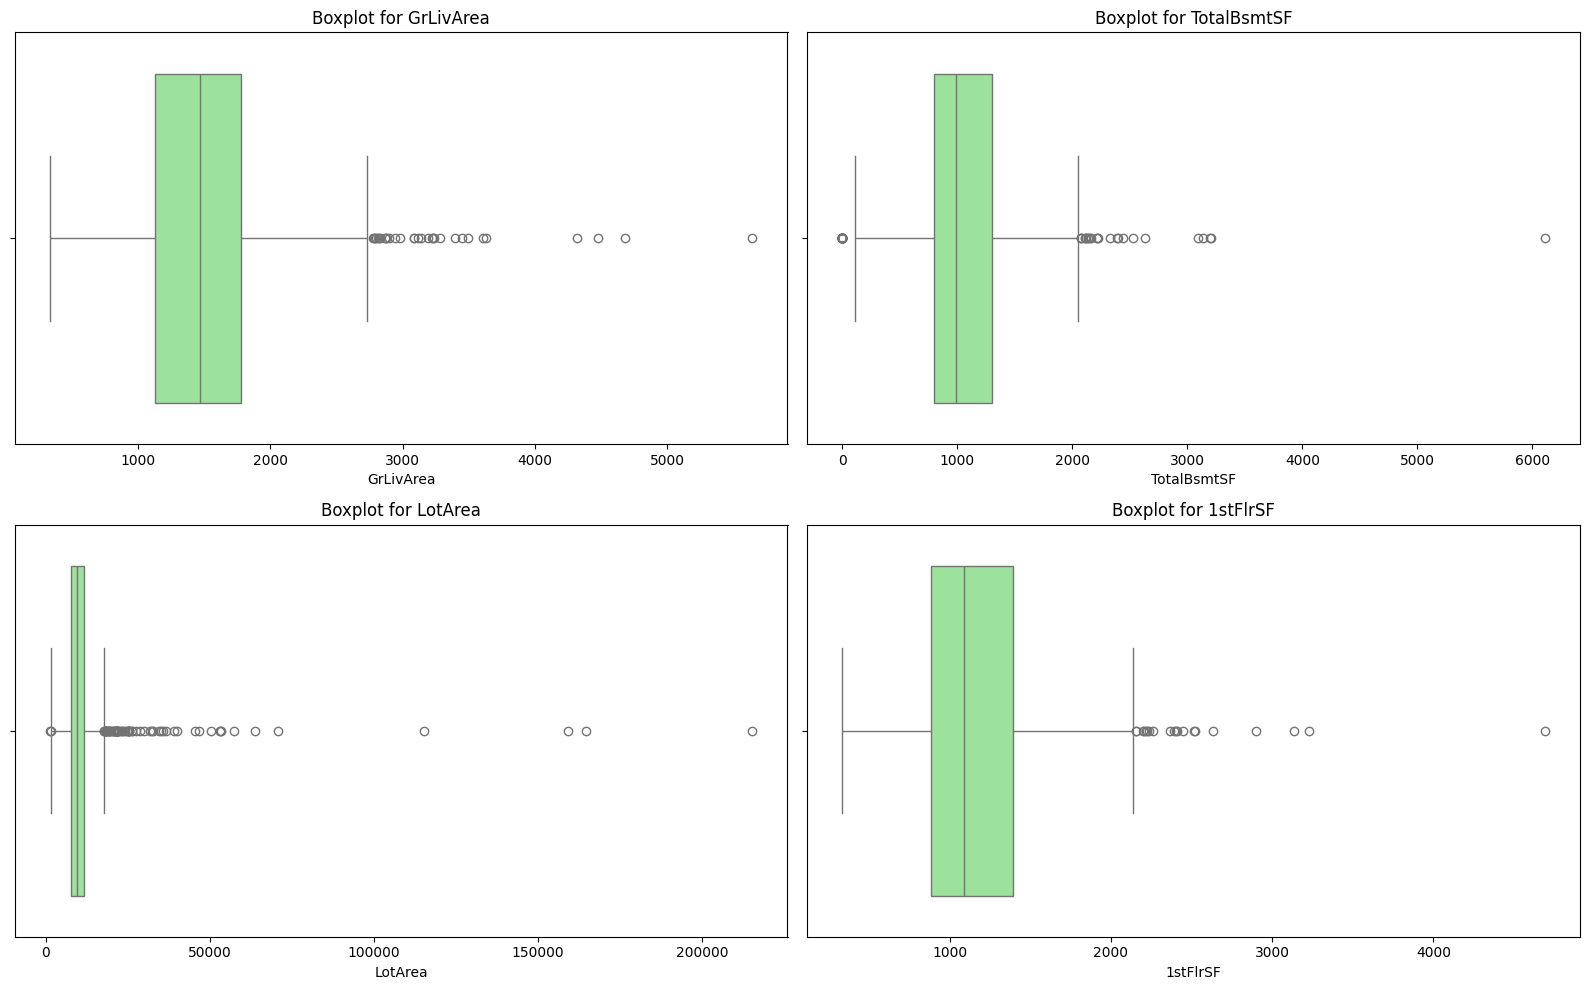

In [171]:
features_to_check = ['GrLivArea', 'TotalBsmtSF', 'LotArea', '1stFlrSF']

plt.figure(figsize=(16, 10))

for i, col in enumerate(features_to_check):
    plt.subplot(2, 2, i + 1)
    sns.boxplot(x=Train[col], color='lightgreen')
    plt.title(f'Boxplot for {col}')

plt.tight_layout()
plt.show()

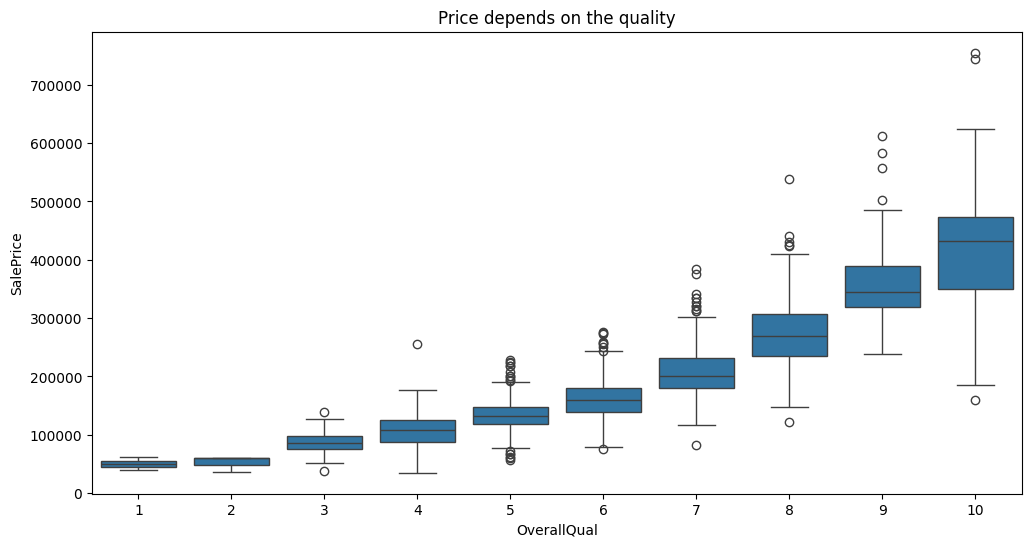

In [172]:
plt.figure(figsize=(12, 6))
sns.boxplot(x='OverallQual', y='SalePrice', data=Train)
plt.title('Price depends on the quality')
plt.show()

Text(0.5, 1.0, 'Sale price distibution')

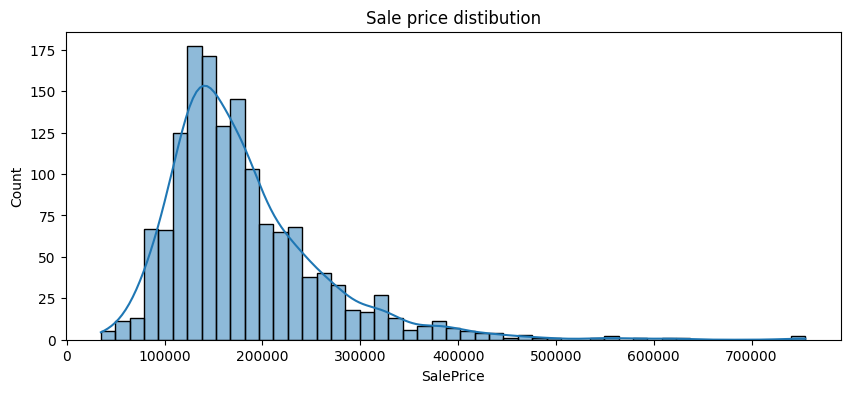

In [173]:
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(10,4))
sns.histplot(Train['SalePrice'], kde=True)
plt.title('Sale price distibution')


Looks like log-normal distibution, to my mind is's better convert to normal

### EDA results

1) Data contains a lot of data gaps
2) **Average by material quality** and **Average by rooms count** and **Average by garage cars places count** and **Live area** have correlation with price
3) Crysis directly affects price, see https://en.wikipedia.org/wiki/2008_financial_crisis
4) Outlines not big, however i will reduce them


## Data processing


In [174]:
Train = Train.drop('Id', axis=1)
Train = Train.drop(Train[Train['GrLivArea'] > 4000].index)
Train = Train.drop(Train[Train['TotalBsmtSF'] > 6000].index)


In [175]:
Train["SalePrice"] = np.log1p(Train["SalePrice"])


## Feature Engineering

New features derived from domain knowledge: house age, years since remodel, combined square footage, total bathrooms, porch area, and quality × living area interaction.

In [176]:
def add_features(df):
    df = df.copy()
    df['HouseAge']  = df['YrSold'] - df['YearBuilt']
    df['RemodAge']  = df['YrSold'] - df['YearRemodAdd']
    df['TotalSF']   = df['TotalBsmtSF'] + df['1stFlrSF'] + df['2ndFlrSF']
    df['TotalBaths'] = df['FullBath'] + 0.5*df['HalfBath'] + df['BsmtFullBath'] + 0.5*df['BsmtHalfBath']
    df['PorchArea'] = df['OpenPorchSF'] + df['EnclosedPorch'] + df['3SsnPorch'] + df['ScreenPorch']
    df['QualArea']  = df['OverallQual'] * df['GrLivArea']
    return df

Train = add_features(Train)
new_feats = ['HouseAge', 'RemodAge', 'TotalSF', 'TotalBaths', 'PorchArea', 'QualArea']
display(Train[new_feats].head())

,HouseAge,RemodAge,TotalSF,TotalBaths,PorchArea,QualArea
0,5,5,2566,3.5,61,11970
1,31,31,2524,2.5,0,7572
2,7,6,2706,3.5,42,12502
3,91,36,2473,2.0,307,12019
4,8,8,3343,3.5,84,17584


In [177]:
corr_series = (
    Train[new_feats + ['SalePrice']]
    .corr()['SalePrice']
    .drop('SalePrice')
    .sort_values(ascending=False)
    .rename('Correlation with SalePrice')
    .to_frame()
    .round(3)
)
display(corr_series)

,Correlation with SalePrice
QualArea,0.839
TotalSF,0.822
TotalBaths,0.673
PorchArea,0.199
RemodAge,-0.571
HouseAge,-0.590


### Constant & Correlated Features

In [178]:
X_temp = Train.drop('SalePrice', axis=1)
const_cols = [c for c in X_temp.columns if X_temp[c].nunique() <= 1]
display(pd.DataFrame({'Constant features (nunique ≤ 1)': const_cols or ['None found']}))

,Constant features (nunique ≤ 1)
0,None found


In [179]:
num_cols_temp = X_temp.select_dtypes(include=['int64', 'float64']).columns.tolist()
corr_mat = X_temp[num_cols_temp].corr().abs()
upper = corr_mat.where(np.triu(np.ones(corr_mat.shape), k=1).astype(bool))
pairs = [
    (col, row, round(float(upper.loc[row, col]), 3))
    for col in upper.columns
    for row in upper.index
    if pd.notna(upper.loc[row, col]) and upper.loc[row, col] > 0.85
]
display(
    pd.DataFrame(pairs, columns=['Feature 1', 'Feature 2', 'Correlation'])
    .sort_values('Correlation', ascending=False)
    .reset_index(drop=True)
)

,Feature 1,Feature 2,Correlation
0,HouseAge,YearBuilt,0.999
1,RemodAge,YearRemodAdd,0.998
2,QualArea,GrLivArea,0.920
3,GarageArea,GarageCars,0.887
4,QualArea,TotalSF,0.870
5,TotalSF,GrLivArea,0.860


In [180]:
Train.isnull().sum()[Train.isnull().sum() > 0]
X = Train.drop("SalePrice", axis=1)
y = Train["SalePrice"]


let's fills categorials with None to string categorial values

In [181]:
num_cols = X.select_dtypes(include=['int64', 'float64']).columns.tolist()

cat_cols_none = [
    'PoolQC', 'Alley', 'FireplaceQu', 'GarageType', 'GarageFinish',
    'GarageQual', 'GarageCond', 'BsmtQual', 'BsmtCond', 'BsmtExposure',
    'BsmtFinType1', 'BsmtFinType2', 'MasVnrType', 'Fence', 'MiscFeature'
]

cat_cols_mode = [col for col in X.select_dtypes(include=['object', 'str']).columns
                 if col not in cat_cols_none]



In [182]:
num_pipeline = Pipeline([
    ('imputer', SimpleImputer(strategy='median')),
    ('scaler', StandardScaler())
  ])
num_pipeline

,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators ` for more details.","[('imputer', ...), ('scaler', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing `.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
,"missing_values missing_values: int, float, str, np.nan, None or pandas.NA, default=np.nanThe placeholder for the missing values. All occurrences of`missing_values` will be imputed. For pandas' dataframes withnullable integer dtypes with missing values, `missing_values`can be set to either `np.nan` or `pd.NA`.",nan
,"strategy strategy: str or Callable, default='mean'The imputation strategy.- If ""mean"", then replace missing values using the mean along each column. Can only be used with numeric data.- If ""median"", then replace missing values using the median along each column. Can only be used with numeric data.- If ""most_frequent"", then replace missing using the most frequent value along each column. Can be used with strings or numeric data. If there is more than one such value, only the smallest is returned.- If ""constant"", then replace missing values with fill_value. Can be used with strings or numeric data.- If an instance of Callable, then replace missing values using the scalar statistic returned by running the callable over a dense 1d array containing non-missing values of each column... versionadded:: 0.20 strategy=""constant"" for fixed value imputation... versionadded:: 1.5 strategy=callable for custom value imputation.",'median'
,"fill_value fill_value: str or numerical value, default=NoneWhen strategy == ""constant"", `fill_value` is used to replace alloccurrences of missing_values. For string or object data types,`fill_value` must be a string.If `None`, `fill_value` will be 0 when imputing numericaldata and ""missing_value"" for strings or object data types.",None
,"copy copy: bool, default=TrueIf True, a copy of X will be created. If False, imputation willbe done in-place whenever possible. Note that, in the following cases,a new copy will always be made, even if `copy=False`:- If `X` is not an array of floating values;- If `X` is encoded as a CSR matrix;- If `add_indicator=True`.",True
,"add_indicator add_indicator: bool, default=FalseIf True, a :class:`MissingIndicator` transform will stack onto outputof the imputer's transform. This allows a predictive estimatorto account for missingness despite imputation. If a f

In [183]:
cat_none_pipeline = Pipeline([
    ('imputer', SimpleImputer(strategy='constant', fill_value='None')),
    ('ohe', OneHotEncoder(handle_unknown='ignore', sparse_output=False))
])
cat_none_pipeline

,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators ` for more details.","[('imputer', ...), ('ohe', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing `.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
,"missing_values missing_values: int, float, str, np.nan, None or pandas.NA, default=np.nanThe placeholder for the missing values. All occurrences of`missing_values` will be imputed. For pandas' dataframes withnullable integer dtypes with missing values, `missing_values`can be set to either `np.nan` or `pd.NA`.",nan
,"strategy strategy: str or Callable, default='mean'The imputation strategy.- If ""mean"", then replace missing values using the mean along each column. Can only be used with numeric data.- If ""median"", then replace missing values using the median along each column. Can only be used with numeric data.- If ""most_frequent"", then replace missing using the most frequent value along each column. Can be used with strings or numeric data. If there is more than one such value, only the smallest is returned.- If ""constant"", then replace missing values with fill_value. Can be used with strings or numeric data.- If an instance of Callable, then replace missing values using the scalar statistic returned by running the callable over a dense 1d array containing non-missing values of each column... versionadded:: 0.20 strategy=""constant"" for fixed value imputation... versionadded:: 1.5 strategy=callable for custom value imputation.",'constant'
,"fill_value fill_value: str or numerical value, default=NoneWhen strategy == ""constant"", `fill_value` is used to replace alloccurrences of missing_values. For string or object data types,`fill_value` must be a string.If `None`, `fill_value` will be 0 when imputing numericaldata and ""missing_value"" for strings or object data types.",'None'
,"copy copy: bool, default=TrueIf True, a copy of X will be created. If False, imputation willbe done in-place whenever possible. Note that, in the following cases,a new copy will always be made, even if `copy=False`:- If `X` is not an array of floating values;- If `X` is encoded as a CSR matrix;- If `add_indicator=True`.",True
,"add_indicator add_indicator: bool, default=FalseIf True, a :class:`MissingIndicator` transform will stack onto outputof the imputer's transform. This allows a predictive estimatorto account for missingness despite imputation. If a 

In [184]:
cat_mode_pipeline = Pipeline([
    ('imputer', SimpleImputer(strategy='most_frequent')),
    ('ohe', OneHotEncoder(handle_unknown='ignore', sparse_output=False))
])
cat_mode_pipeline

,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators ` for more details.","[('imputer', ...), ('ohe', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing `.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
,"missing_values missing_values: int, float, str, np.nan, None or pandas.NA, default=np.nanThe placeholder for the missing values. All occurrences of`missing_values` will be imputed. For pandas' dataframes withnullable integer dtypes with missing values, `missing_values`can be set to either `np.nan` or `pd.NA`.",nan
,"strategy strategy: str or Callable, default='mean'The imputation strategy.- If ""mean"", then replace missing values using the mean along each column. Can only be used with numeric data.- If ""median"", then replace missing values using the median along each column. Can only be used with numeric data.- If ""most_frequent"", then replace missing using the most frequent value along each column. Can be used with strings or numeric data. If there is more than one such value, only the smallest is returned.- If ""constant"", then replace missing values with fill_value. Can be used with strings or numeric data.- If an instance of Callable, then replace missing values using the scalar statistic returned by running the callable over a dense 1d array containing non-missing values of each column... versionadded:: 0.20 strategy=""constant"" for fixed value imputation... versionadded:: 1.5 strategy=callable for custom value imputation.",'most_frequent'
,"fill_value fill_value: str or numerical value, default=NoneWhen strategy == ""constant"", `fill_value` is used to replace alloccurrences of missing_values. For string or object data types,`fill_value` must be a string.If `None`, `fill_value` will be 0 when imputing numericaldata and ""missing_value"" for strings or object data types.",None
,"copy copy: bool, default=TrueIf True, a copy of X will be created. If False, imputation willbe done in-place whenever possible. Note that, in the following cases,a new copy will always be made, even if `copy=False`:- If `X` is not an array of floating values;- If `X` is encoded as a CSR matrix;- If `add_indicator=True`.",True
,"add_indicator add_indicator: bool, default=FalseIf True, a :class:`MissingIndicator` transform will stack onto outputof the imputer's transform. This allows a predictive estimatorto account for missingness despite imputation. If

In [185]:
preprocessor = ColumnTransformer(
    transformers=[
        ('num', num_pipeline, num_cols),
        ('cat_none', cat_none_pipeline, cat_cols_none),
        ('cat_mode', cat_mode_pipeline, cat_cols_mode)
    ]
)
preprocessor

,"transformers transformers: list of tuplesList of (name, transformer, columns) tuples specifying thetransformer objects to be applied to subsets of the data.name : str Like in Pipeline and FeatureUnion, this allows the transformer and its parameters to be set using ``set_params`` and searched in grid search.transformer : {'drop', 'passthrough'} or estimator Estimator must support :term:`fit` and :term:`transform`. Special-cased strings 'drop' and 'passthrough' are accepted as well, to indicate to drop the columns or to pass them through untransformed, respectively.columns : str, array-like of str, int, array-like of int, array-like of bool, slice or callable Indexes the data on its second axis. Integers are interpreted as positional columns, while strings can reference DataFrame columns by name. A scalar string or int should be used where ``transformer`` expects X to be a 1d array-like (vector), otherwise a 2d array will be passed to the transformer. A callable is passed the input data `X` and can return any of the above. To select multiple columns by name or dtype, you can use :obj:`make_column_selector`.","[('num', ...), ('cat_none', ...), ...]"
,"remainder remainder: {'drop', 'passthrough'} or estimator, default='drop'By default, only the specified columns in `transformers` aretransformed and combined in the output, and the non-specifiedcolumns are dropped. (default of ``'drop'``).By specifying ``remainder='passthrough'``, all remaining columns thatwere not specified in `transformers`, but present in the data passedto `fit` will be automatically passed through. This subset of columnsis concatenated with the output of the transformers. For dataframes,extra columns not seen during `fit` will be excluded from the outputof `transform`.By setting ``remainder`` to be an estimator, the remainingnon-specified columns will use the ``remainder`` estimator. Theestimator must support :term:`fit` and :term:`transform`.Note that using this feature requires that the DataFrame columnsinput at :term:`fit` and :term:`transform` have identical order.",'drop'
,"sparse_threshold sparse_threshold: float, default=0.3If the output of the different transformers contains sparse matrices,these will be stacked as a sparse matrix if the overall density islower than this value. Use ``sparse_threshold=0`` to always returndense. When the transformed output consists of all dense data, thestacked result will be dense, and this keyword will be ignored.",0.3
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary `for more details.",None
,"transformer_weights transformer_weights: dict, default=NoneMultiplicative weights for features per transformer. The output of thetransformer is multiplied by these weights. Keys are transformer names,values the weights.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each transformer will beprinted as it is completed.",False
,"verbose_feature_names_out verbose_feature_names_out: bool, str or Callable[[str, str], str], default=True- If True, :meth:`ColumnTransformer.get_feature_names_out` will prefix all feature names with the name of the transformer that generated that feature. It is equivalent to setting `verbose_feature_names_out=""{transformer_name}__{feature_name}""`.- If False, :meth:`ColumnTransformer.get_feature_names_out` will not prefix any feature names and will error if feature names are not unique.- If ``Callable[[str, str], str]``, :meth:`ColumnTransformer.get_feature_names_out` will rename all the features using the name of the transformer. The first argument of the callable is the transformer name and the second argument is the feature name. The returned string will be the new feature name.- If ``str``, it must be a string ready for formatting. The given string will be formatted using two field names: ``transformer_name`` and ``feature_name

In [186]:
cat_pipeline_simple = Pipeline([
    ('imputer', SimpleImputer(strategy='most_frequent')),
    ('ordinal', OrdinalEncoder(handle_unknown='use_encoded_value', unknown_value=-1))
])
cat_pipeline_simple

,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators ` for more details.","[('imputer', ...), ('ordinal', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing `.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
,"missing_values missing_values: int, float, str, np.nan, None or pandas.NA, default=np.nanThe placeholder for the missing values. All occurrences of`missing_values` will be imputed. For pandas' dataframes withnullable integer dtypes with missing values, `missing_values`can be set to either `np.nan` or `pd.NA`.",nan
,"strategy strategy: str or Callable, default='mean'The imputation strategy.- If ""mean"", then replace missing values using the mean along each column. Can only be used with numeric data.- If ""median"", then replace missing values using the median along each column. Can only be used with numeric data.- If ""most_frequent"", then replace missing using the most frequent value along each column. Can be used with strings or numeric data. If there is more than one such value, only the smallest is returned.- If ""constant"", then replace missing values with fill_value. Can be used with strings or numeric data.- If an instance of Callable, then replace missing values using the scalar statistic returned by running the callable over a dense 1d array containing non-missing values of each column... versionadded:: 0.20 strategy=""constant"" for fixed value imputation... versionadded:: 1.5 strategy=callable for custom value imputation.",'most_frequent'
,"fill_value fill_value: str or numerical value, default=NoneWhen strategy == ""constant"", `fill_value` is used to replace alloccurrences of missing_values. For string or object data types,`fill_value` must be a string.If `None`, `fill_value` will be 0 when imputing numericaldata and ""missing_value"" for strings or object data types.",None
,"copy copy: bool, default=TrueIf True, a copy of X will be created. If False, imputation willbe done in-place whenever possible. Note that, in the following cases,a new copy will always be made, even if `copy=False`:- If `X` is not an array of floating values;- If `X` is encoded as a CSR matrix;- If `add_indicator=True`.",True
,"add_indicator add_indicator: bool, default=FalseIf True, a :class:`MissingIndicator` transform will stack onto outputof the imputer's transform. This allows a predictive estimatorto account for missingness despite imputation

In [187]:
preprocessor_tree = ColumnTransformer(
    transformers=[
        ('num', num_pipeline, num_cols),
        ('cat', cat_pipeline_simple, cat_cols_none + cat_cols_mode)
    ]
)
preprocessor_tree

,"transformers transformers: list of tuplesList of (name, transformer, columns) tuples specifying thetransformer objects to be applied to subsets of the data.name : str Like in Pipeline and FeatureUnion, this allows the transformer and its parameters to be set using ``set_params`` and searched in grid search.transformer : {'drop', 'passthrough'} or estimator Estimator must support :term:`fit` and :term:`transform`. Special-cased strings 'drop' and 'passthrough' are accepted as well, to indicate to drop the columns or to pass them through untransformed, respectively.columns : str, array-like of str, int, array-like of int, array-like of bool, slice or callable Indexes the data on its second axis. Integers are interpreted as positional columns, while strings can reference DataFrame columns by name. A scalar string or int should be used where ``transformer`` expects X to be a 1d array-like (vector), otherwise a 2d array will be passed to the transformer. A callable is passed the input data `X` and can return any of the above. To select multiple columns by name or dtype, you can use :obj:`make_column_selector`.","[('num', ...), ('cat', ...)]"
,"remainder remainder: {'drop', 'passthrough'} or estimator, default='drop'By default, only the specified columns in `transformers` aretransformed and combined in the output, and the non-specifiedcolumns are dropped. (default of ``'drop'``).By specifying ``remainder='passthrough'``, all remaining columns thatwere not specified in `transformers`, but present in the data passedto `fit` will be automatically passed through. This subset of columnsis concatenated with the output of the transformers. For dataframes,extra columns not seen during `fit` will be excluded from the outputof `transform`.By setting ``remainder`` to be an estimator, the remainingnon-specified columns will use the ``remainder`` estimator. Theestimator must support :term:`fit` and :term:`transform`.Note that using this feature requires that the DataFrame columnsinput at :term:`fit` and :term:`transform` have identical order.",'drop'
,"sparse_threshold sparse_threshold: float, default=0.3If the output of the different transformers contains sparse matrices,these will be stacked as a sparse matrix if the overall density islower than this value. Use ``sparse_threshold=0`` to always returndense. When the transformed output consists of all dense data, thestacked result will be dense, and this keyword will be ignored.",0.3
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary `for more details.",None
,"transformer_weights transformer_weights: dict, default=NoneMultiplicative weights for features per transformer. The output of thetransformer is multiplied by these weights. Keys are transformer names,values the weights.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each transformer will beprinted as it is completed.",False
,"verbose_feature_names_out verbose_feature_names_out: bool, str or Callable[[str, str], str], default=True- If True, :meth:`ColumnTransformer.get_feature_names_out` will prefix all feature names with the name of the transformer that generated that feature. It is equivalent to setting `verbose_feature_names_out=""{transformer_name}__{feature_name}""`.- If False, :meth:`ColumnTransformer.get_feature_names_out` will not prefix any feature names and will error if feature names are not unique.- If ``Callable[[str, str], str]``, :meth:`ColumnTransformer.get_feature_names_out` will rename all the features using the name of the transformer. The first argument of the callable is the transformer name and the second argument is the feature name. The returned string will be the new feature name.- If ``str``, it must be a string ready for formatting. The given string will be formatted using two field names: ``transformer_name`` and ``feature_name``. e.g. `

In [188]:
X = Train.drop("SalePrice", axis=1)
y = Train["SalePrice"]

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

y_binned = pd.qcut(y, q=10, labels=False)


skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
y_binned_train = pd.qcut(y_train, q=10, labels=False)


### 1-fold vs 5-fold CV comparison

Stratified 5-fold produces a more reliable estimate of generalization error than a single holdout split.

In [189]:
ridge_cv_pipe = Pipeline([
    ('preprocessor', preprocessor),
    ('ridge', Ridge(alpha=1.0))
])

ss1 = ShuffleSplit(n_splits=1, test_size=0.2, random_state=42)
scores_1 = cross_val_score(ridge_cv_pipe, X, y, cv=ss1, scoring='neg_root_mean_squared_error', n_jobs=-1)
scores_5 = cross_val_score(ridge_cv_pipe, X, y, cv=5, scoring='neg_root_mean_squared_error', n_jobs=-1)

display(pd.DataFrame({
    'CV Strategy': ['1-fold (holdout)', '5-fold CV'],
    'Mean RMSE': [-scores_1.mean(), -scores_5.mean()],
    'Std RMSE':  [scores_1.std(),   scores_5.std()]
}).round(5))

,CV Strategy,Mean RMSE,Std RMSE
0,1-fold (holdout),0.12322,0.00000
1,5-fold CV,0.12018,0.00862


## Models training

### Linear models

In [190]:
lr_pipeline = Pipeline([
    ('preprocessor', preprocessor),
    ('lr', LinearRegression())
])

lr_cv_scores = cross_val_score(
    lr_pipeline,
    X_train, y_train,
    cv=skf.split(X_train, y_binned_train),
    scoring='neg_mean_squared_error',
    n_jobs=-1
)
lr_pipeline.fit(X_train, y_train)

best_lr_rmse = np.sqrt(-lr_cv_scores.mean())
print(f"Linear Regression CV RMSE: {best_lr_rmse:.5f}")


Linear Regression CV RMSE: 0.13067


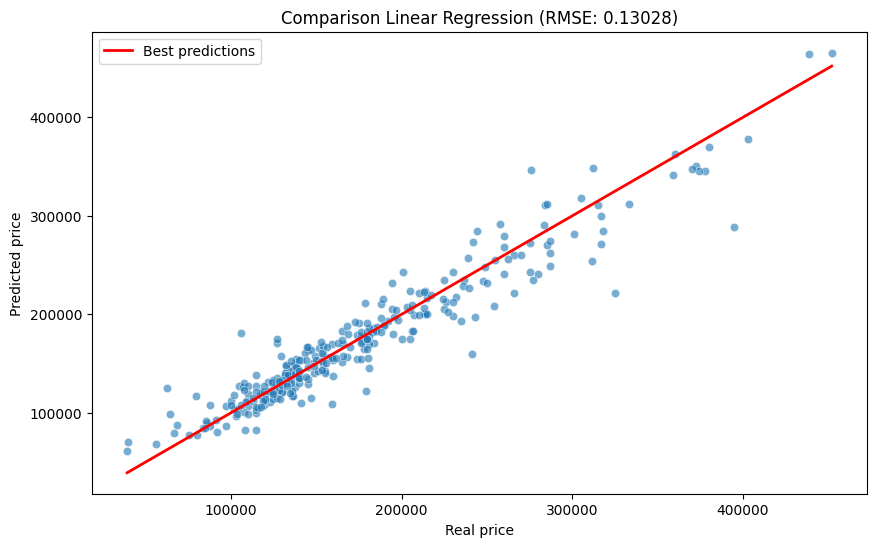

Avg loss (LinearRegression): 9.13%


In [191]:
y_test_pred = lr_pipeline.predict(X_test)
rmse_lr = np.sqrt(mean_squared_error(y_test, y_test_pred))

y_test_real      = np.expm1(y_test)
y_test_pred_real = np.expm1(y_test_pred)

plt.figure(figsize=(10, 6))
sns.scatterplot(x=y_test_real, y=y_test_pred_real, alpha=0.6)
line_coords = [y_test_real.min(), y_test_real.max()]
plt.plot(line_coords, line_coords, color='red', lw=2, label='Best predictions')
plt.xlabel('Real price')
plt.ylabel('Predicted price')
plt.title(f'Comparison Linear Regression (RMSE: {rmse_lr:.5f})')
plt.legend()
plt.show()

mape = mean_absolute_percentage_error(y_test_real, y_test_pred_real)
print(f'Avg loss (LinearRegression): {mape*100:.2f}%')


In [192]:
full_pipeline = Pipeline([
    ('preprocessor', preprocessor),
    ('lasso', Lasso())
])

param_grid = {
    'lasso__alpha': [0.05, 0.1, 0.5, 1, 5, 10, 15, 20, 30, 50],
}

grid_search_lasso = GridSearchCV(
    full_pipeline,
    param_grid,
    cv=skf.split(X_train, y_binned_train),
    scoring='neg_mean_squared_error',
    verbose=1,
    n_jobs=-1
)

grid_search_lasso.fit(X_train, y_train)


print(f"Best params: {grid_search_lasso.best_params_}")

best_rmse_lasso = np.sqrt(-grid_search_lasso.best_score_)
print(f"Best RMSE lasso: {best_rmse_lasso:.5f}")


Fitting 5 folds for each of 10 candidates, totalling 50 fits
Best params: {'lasso__alpha': 0.05}
Best RMSE lasso: 0.15927


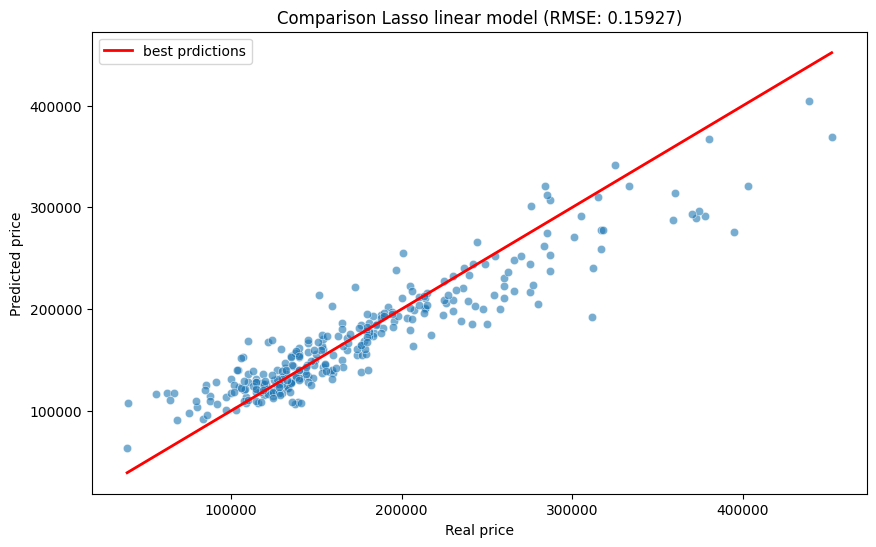

Avg loss: 12.67%


In [193]:
y_test_pred = grid_search_lasso.predict(X_test)

y_test_real = np.expm1(y_test)
y_test_pred_real = np.expm1(y_test_pred)

plt.figure(figsize=(10, 6))

sns.scatterplot(x=y_test_real, y=y_test_pred_real, alpha=0.6)

line_coords = [y_test_real.min(), y_test_real.max()]
plt.plot(line_coords, line_coords, color='red', lw=2, label='best prdictions')

plt.xlabel('Real price')
plt.ylabel('Predicted price')
plt.title(f'Comparison Lasso linear model (RMSE: {best_rmse_lasso:.5f})')
plt.legend()
plt.show()

y_true_dollars = np.expm1(y_test)
y_pred_dollars = np.expm1(y_test_pred)


mape = mean_absolute_percentage_error(y_true_dollars, y_pred_dollars)
print(f"Avg loss: {mape*100:.2f}%")



### Ridge modek

In [194]:
full_pipeline = Pipeline([
    ('preprocessor', preprocessor),
    ('ridge', Ridge())
])

param_grid = {
    'ridge__alpha': [0.05, 0.1, 0.5, 1, 5, 10, 15, 20, 30, 50],
}

grid_search_ridge = GridSearchCV(
    full_pipeline,
    param_grid,
    cv=skf.split(X_train, y_binned_train),
    scoring='neg_mean_squared_error',
    verbose=1,
    n_jobs=-1
)

grid_search_ridge.fit(X_train, y_train)


print(f"Best params: {grid_search_ridge.best_params_}")
best_ridge_rmse = np.sqrt(-grid_search_ridge.best_score_)
print(f"Ridge Best RMSE (CV): {best_ridge_rmse:.5f}")


y_test_pred_ridge = grid_search_ridge.predict(X_test)
rmse_test_ridge = np.sqrt(mean_squared_error(y_test, y_test_pred_ridge))
print(f"Ridge Test RMSE: {rmse_test_ridge:.5f}")

Fitting 5 folds for each of 10 candidates, totalling 50 fits
Best params: {'ridge__alpha': 15}
Ridge Best RMSE (CV): 0.11426
Ridge Test RMSE: 0.12211


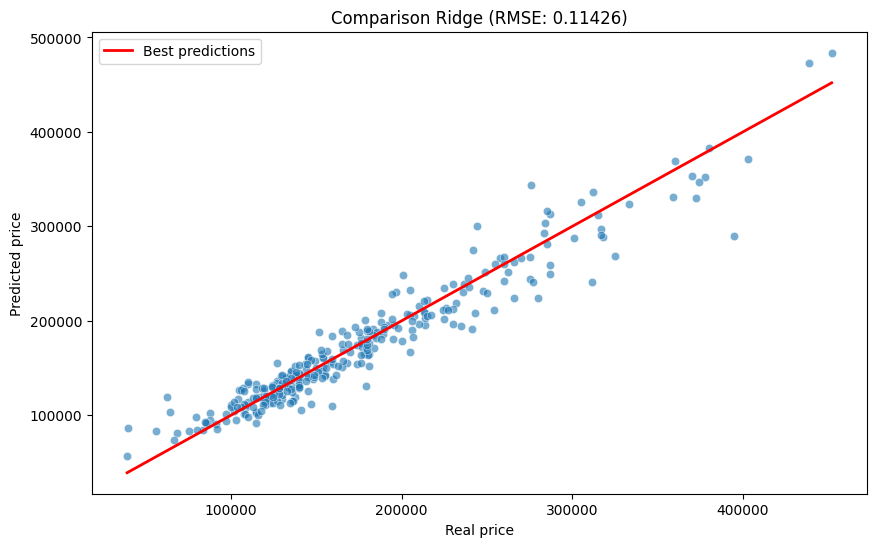

Avg loss (Ridge): 8.69%


In [195]:
y_test_pred = grid_search_ridge.predict(X_test)

y_test_real     = np.expm1(y_test)
y_test_pred_real = np.expm1(y_test_pred)

plt.figure(figsize=(10, 6))
sns.scatterplot(x=y_test_real, y=y_test_pred_real, alpha=0.6)
line_coords = [y_test_real.min(), y_test_real.max()]
plt.plot(line_coords, line_coords, color='red', lw=2, label='Best predictions')
plt.xlabel('Real price')
plt.ylabel('Predicted price')
plt.title(f'Comparison Ridge (RMSE: {best_ridge_rmse:.5f})')
plt.legend()
plt.show()

mape = mean_absolute_percentage_error(np.expm1(y_test), np.expm1(y_test_pred))
print(f'Avg loss (Ridge): {mape*100:.2f}%')

In [196]:
full_pipeline = Pipeline([
    ('preprocessor', preprocessor),
    ('ridge', ElasticNet())
])

param_grid = {
    'ridge__alpha': [0.01, 0.05],
    'ridge__l1_ratio': [0.1, 0.3],
    'ridge__max_iter': [1000, 3000],
    'ridge__tol': [0.0001, 0.001]
}

grid_search_elastic_net = GridSearchCV(
    full_pipeline,
    param_grid,
    cv=skf.split(X_train, y_binned_train),
    scoring='neg_mean_squared_error',
    verbose=1,
    n_jobs=-1
)

grid_search_elastic_net.fit(X_train, y_train)


print(f"Best params: {grid_search_elastic_net.best_params_}")

best_rmse = np.sqrt(-grid_search_elastic_net.best_score_)
print(f"Best RMSE: {best_rmse:.5f}")

Fitting 5 folds for each of 16 candidates, totalling 80 fits
Best params: {'ridge__alpha': 0.01, 'ridge__l1_ratio': 0.1, 'ridge__max_iter': 1000, 'ridge__tol': 0.0001}
Best RMSE: 0.11359


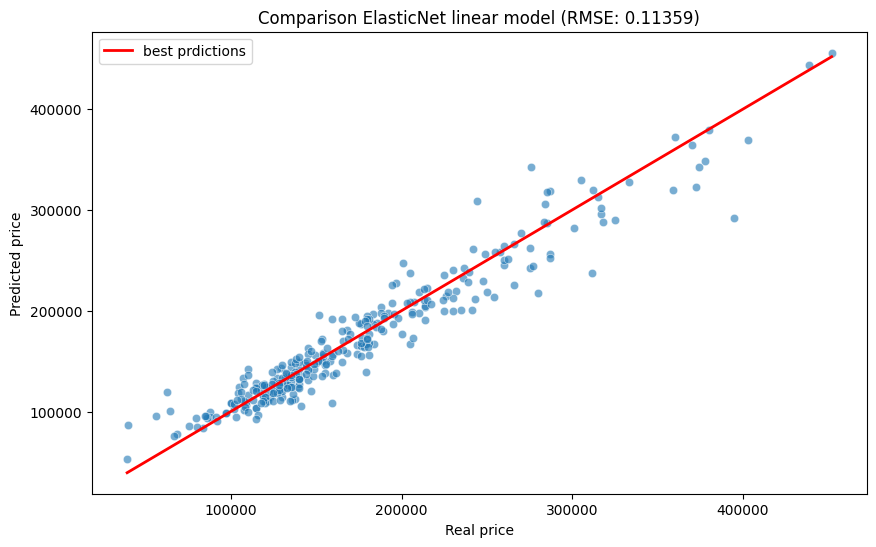

Avg loss: 8.70%


In [197]:
y_test_pred = grid_search_elastic_net.predict(X_test)

y_test_real = np.expm1(y_test)
y_test_pred_real = np.expm1(y_test_pred)

plt.figure(figsize=(10, 6))

sns.scatterplot(x=y_test_real, y=y_test_pred_real, alpha=0.6)

line_coords = [y_test_real.min(), y_test_real.max()]
plt.plot(line_coords, line_coords, color='red', lw=2, label='best prdictions')

plt.xlabel('Real price')
plt.ylabel('Predicted price')
plt.title(f'Comparison ElasticNet linear model (RMSE: {best_rmse:.5f})')
plt.legend()
plt.show()

y_true_dollars = np.expm1(y_test)
y_pred_dollars = np.expm1(y_test_pred)


mape = mean_absolute_percentage_error(y_true_dollars, y_pred_dollars)
print(f"Avg loss: {mape*100:.2f}%")



### KNN


In [198]:
full_pipeline = Pipeline([
    ('preprocessor', preprocessor),
    ('knn', KNeighborsRegressor())
])

param_grid = {
    'knn__n_neighbors': [3, 5, 7, 10, 15, 20, 25],
    'knn__weights':     ['uniform', 'distance'],
    'knn__metric':      ['euclidean', 'manhattan']
}

grid_search_knn = GridSearchCV(
    full_pipeline,
    param_grid,
    cv=skf.split(X_train, y_binned_train),
    scoring='neg_mean_squared_error',
    verbose=1,
    n_jobs=-1
)

grid_search_knn.fit(X_train, y_train)

print(f'Best params: {grid_search_knn.best_params_}')
best_knn_rmse = np.sqrt(-grid_search_knn.best_score_)
print(f'Best RMSE (CV): {best_knn_rmse:.5f}')

Fitting 5 folds for each of 28 candidates, totalling 140 fits
Best params: {'knn__metric': 'manhattan', 'knn__n_neighbors': 7, 'knn__weights': 'distance'}
Best RMSE (CV): 0.15050


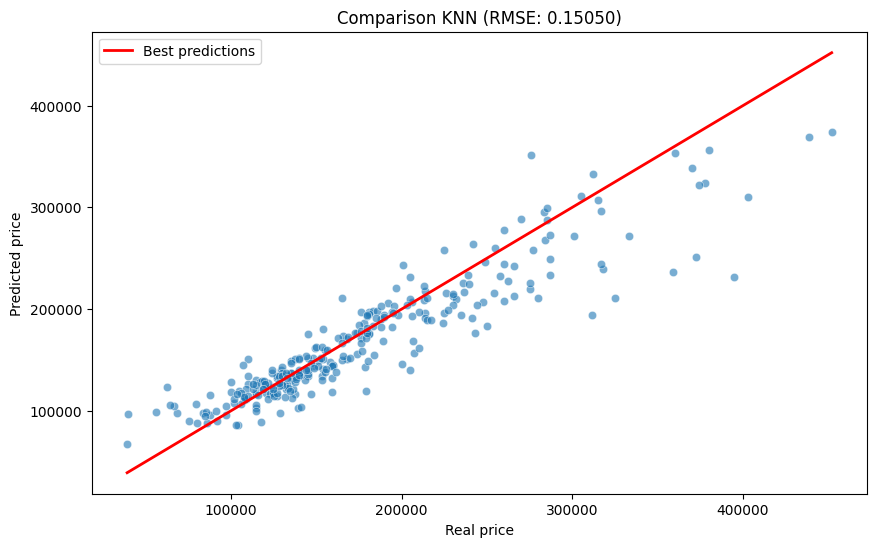

Avg loss (KNN): 11.35%


In [199]:
y_test_pred = grid_search_knn.predict(X_test)

y_test_real      = np.expm1(y_test)
y_test_pred_real = np.expm1(y_test_pred)

plt.figure(figsize=(10, 6))
sns.scatterplot(x=y_test_real, y=y_test_pred_real, alpha=0.6)
line_coords = [y_test_real.min(), y_test_real.max()]
plt.plot(line_coords, line_coords, color='red', lw=2, label='Best predictions')
plt.xlabel('Real price')
plt.ylabel('Predicted price')
plt.title(f'Comparison KNN (RMSE: {best_knn_rmse:.5f})')
plt.legend()
plt.show()

mape = mean_absolute_percentage_error(np.expm1(y_test), np.expm1(y_test_pred))
print(f'Avg loss (KNN): {mape*100:.2f}%')

### SVR

In [200]:
svr_pipeline = Pipeline([
    ('preprocessor', preprocessor),
    ('svr', SVR())
])

param_grid_svr = [
    {
        'svr__kernel': ['rbf'],
        'svr__C': [1, 10, 20],
        'svr__gamma': ['scale', 0.001, 0.01],
        'svr__epsilon': [0.01, 0.1]
    },
]

grid_search_svr = GridSearchCV(
    svr_pipeline,
    param_grid_svr,
    cv=skf.split(X_train, y_binned_train),
    scoring='neg_mean_squared_error',
    verbose=1,
    n_jobs=-1
)

grid_search_svr.fit(X_train, y_train)

print(f"Лучшее ядро и параметры: {grid_search_svr.best_params_}")
best_svr_rmse = np.sqrt(-grid_search_svr.best_score_)
print(f"SVR RMSE: {best_svr_rmse:.5f}")

Fitting 5 folds for each of 18 candidates, totalling 90 fits
Лучшее ядро и параметры: {'svr__C': 10, 'svr__epsilon': 0.01, 'svr__gamma': 0.001, 'svr__kernel': 'rbf'}
SVR RMSE: 0.11088


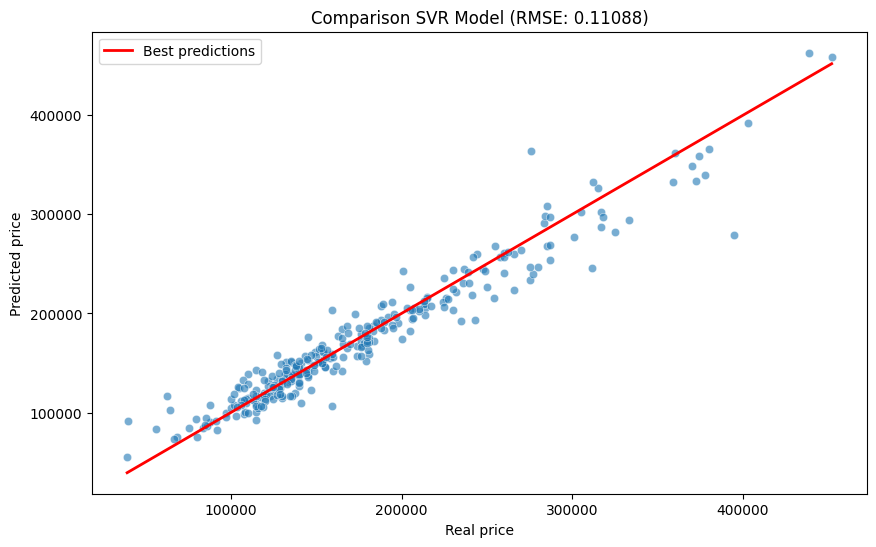

Avg loss (SVR): 7.92%


In [201]:
y_test_pred = grid_search_svr.predict(X_test)

y_test_real = np.expm1(y_test)
y_test_pred_real = np.expm1(y_test_pred)

plt.figure(figsize=(10, 6))

sns.scatterplot(x=y_test_real, y=y_test_pred_real, alpha=0.6)

line_coords = [y_test_real.min(), y_test_real.max()]
plt.plot(line_coords, line_coords, color='red', lw=2, label='Best predictions')

plt.xlabel('Real price')
plt.ylabel('Predicted price')
plt.title(f'Comparison SVR Model (RMSE: {best_svr_rmse:.5f})')
plt.legend()
plt.show()

y_true_dollars = np.expm1(y_test)
y_pred_dollars = np.expm1(y_test_pred)

from sklearn.metrics import mean_absolute_percentage_error
mape = mean_absolute_percentage_error(y_true_dollars, y_pred_dollars)
print(f"Avg loss (SVR): {mape*100:.2f}%")

### Desision tree

In [202]:
desicion_tree_pipeline = Pipeline([
    ('preprocessor', preprocessor_tree),
    ('dt', DecisionTreeRegressor())
])

param_dist_dt = {
    'dt__max_depth':        [2, 3, 5, 7, 10],
    'dt__min_samples_split': [2, 5, 10],
    'dt__min_samples_leaf':  [1, 2, 4],
    'dt__max_features':     ['sqrt', 0.3, 0.5],
    'dt__random_state':     [42]
}

random_search_dt = GridSearchCV(
    desicion_tree_pipeline,
    param_grid=param_dist_dt,
    cv=skf.split(X_train, y_binned_train),
    scoring='neg_mean_squared_error',
    verbose=1,
    n_jobs=-1,
)

random_search_dt.fit(X_train, y_train)

y_pred_dt = random_search_dt.best_estimator_.predict(X_test)
rmse_dt = np.sqrt(mean_squared_error(y_test, y_pred_dt))
print(f'DecisionTree Best Params: {random_search_dt.best_params_}')
print(f'DecisionTree RMSE: {rmse_dt:.5f}')

Fitting 5 folds for each of 135 candidates, totalling 675 fits
DecisionTree Best Params: {'dt__max_depth': 10, 'dt__max_features': 0.5, 'dt__min_samples_leaf': 2, 'dt__min_samples_split': 10, 'dt__random_state': 42}
DecisionTree RMSE: 0.19902


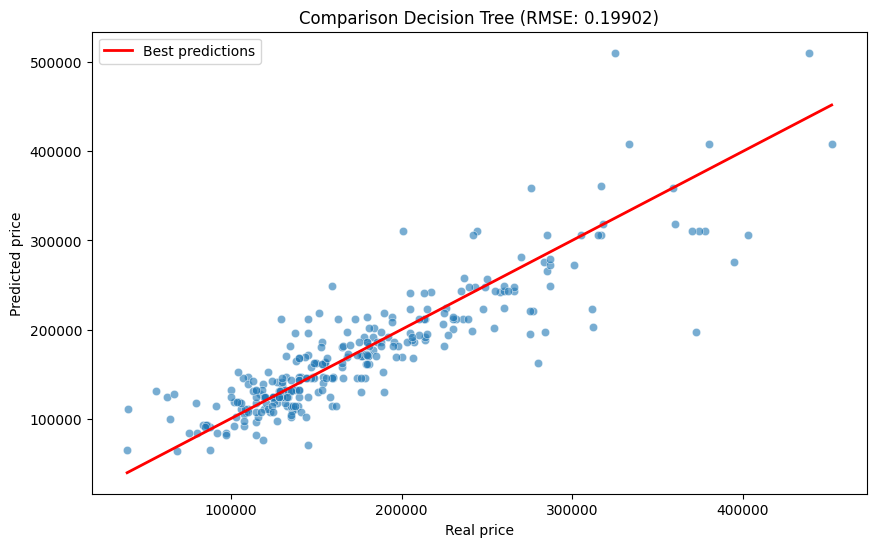

Avg loss (DecisionTree): 14.39%


In [203]:
y_test_pred = random_search_dt.predict(X_test)

y_test_real      = np.expm1(y_test)
y_test_pred_real = np.expm1(y_test_pred)

plt.figure(figsize=(10, 6))
sns.scatterplot(x=y_test_real, y=y_test_pred_real, alpha=0.6)
line_coords = [y_test_real.min(), y_test_real.max()]
plt.plot(line_coords, line_coords, color='red', lw=2, label='Best predictions')
plt.xlabel('Real price')
plt.ylabel('Predicted price')
plt.title(f'Comparison Decision Tree (RMSE: {rmse_dt:.5f})')
plt.legend()
plt.show()

mape = mean_absolute_percentage_error(np.expm1(y_test), np.expm1(y_test_pred))
print(f'Avg loss (DecisionTree): {mape*100:.2f}%')

### Random forest

In [204]:
random_trees_pipeline = Pipeline([
    ('preprocessor', preprocessor_tree),
    ('rt', RandomForestRegressor(n_jobs=-1, random_state=42))
])

param_dist_rt = {
    'rt__n_estimators':      [300, 500, 700],
    'rt__max_depth':         [None, 10, 20],
    'rt__min_samples_split': [2, 5, 10],
    'rt__min_samples_leaf':  [1, 2, 4],
    'rt__max_features':      ['sqrt', 0.3],
    'rt__bootstrap':         [True, False]
}

random_search_rt = RandomizedSearchCV(
    random_trees_pipeline,
    param_distributions=param_dist_rt,
    n_iter=30,
    cv=skf.split(X_train, y_binned_train),
    scoring='neg_mean_squared_error',
    verbose=1,
    n_jobs=-1,
    random_state=42
)

random_search_rt.fit(X_train, y_train)

y_pred_et = random_search_rt.best_estimator_.predict(X_test)
rmse_et = np.sqrt(mean_squared_error(y_test, y_pred_et))
print(f'RandomForest Best Params: {random_search_rt.best_params_}')
print(f'RandomForest RMSE: {rmse_et:.5f}')

Fitting 5 folds for each of 30 candidates, totalling 150 fits
RandomForest Best Params: {'rt__n_estimators': 700, 'rt__min_samples_split': 2, 'rt__min_samples_leaf': 1, 'rt__max_features': 'sqrt', 'rt__max_depth': 20, 'rt__bootstrap': False}
RandomForest RMSE: 0.13677


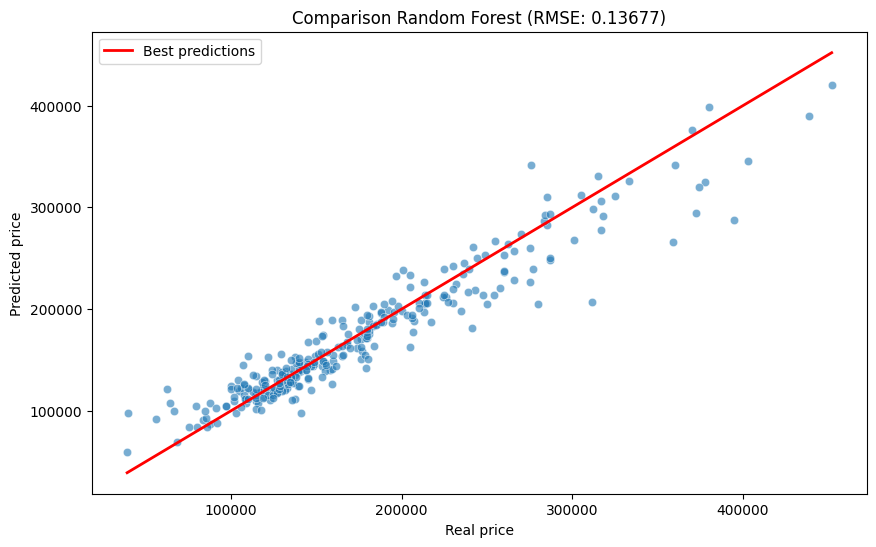

Avg loss (RandomForest): 9.44%


In [205]:
y_test_pred = random_search_rt.predict(X_test)

y_test_real      = np.expm1(y_test)
y_test_pred_real = np.expm1(y_test_pred)

plt.figure(figsize=(10, 6))
sns.scatterplot(x=y_test_real, y=y_test_pred_real, alpha=0.6)
line_coords = [y_test_real.min(), y_test_real.max()]
plt.plot(line_coords, line_coords, color='red', lw=2, label='Best predictions')
plt.xlabel('Real price')
plt.ylabel('Predicted price')
plt.title(f'Comparison Random Forest (RMSE: {rmse_et:.5f})')
plt.legend()
plt.show()

mape = mean_absolute_percentage_error(np.expm1(y_test), np.expm1(y_test_pred))
print(f'Avg loss (RandomForest): {mape*100:.2f}%')

### Catboost

In [206]:
param_dist = {
    'catboost__iterations': [500, 1000],
    'catboost__learning_rate': [0.01, 0.05, 0.15],
    'catboost__depth': [2, 4],
    'catboost__l2_leaf_reg': [1, 3]
}

cat_pipeline = Pipeline([
    ('preprocessor', preprocessor_tree),
    ('catboost', CatBoostRegressor(
        random_state=42,
        verbose=0,
        thread_count=-1
    ))
])

random_search_cat = RandomizedSearchCV(
    cat_pipeline,
    param_distributions=param_dist,
    n_iter=15,
    cv=skf.split(X_train, y_binned_train),
    scoring='neg_mean_squared_error',
    verbose=2,
    n_jobs=2,
    random_state=42
)


random_search_cat.fit(X_train, y_train)

y_pred_cat = random_search_cat.predict(X_test)
rmse_cat = np.sqrt(mean_squared_error(y_test, y_pred_cat))
best_model = random_search_cat.best_estimator_
print(f"Best params: {random_search_cat.best_params_}")
print(f"CatBoost RMSE: {rmse_cat:.5f}")

Fitting 5 folds for each of 15 candidates, totalling 75 fits
Best params: {'catboost__learning_rate': 0.05, 'catboost__l2_leaf_reg': 1, 'catboost__iterations': 500, 'catboost__depth': 4}
CatBoost RMSE: 0.11897


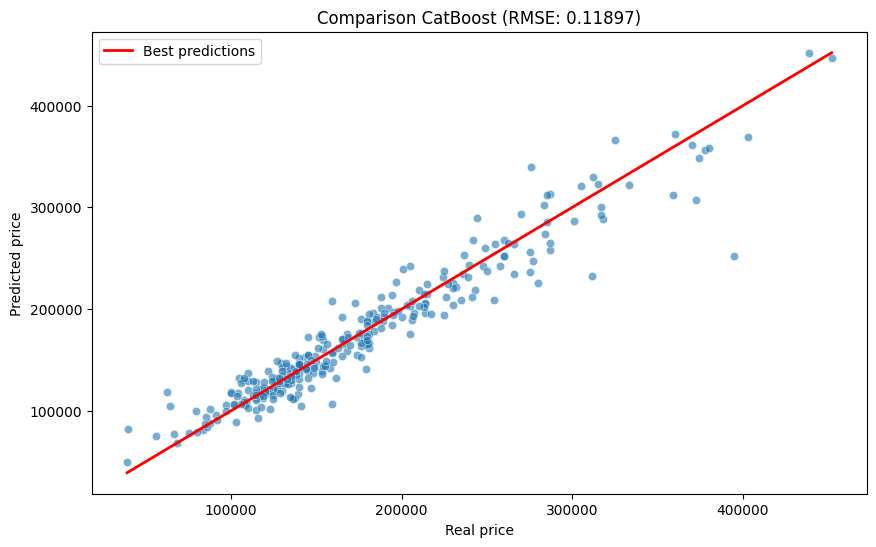

Avg loss (CatBoost): 8.20%


In [207]:
y_test_pred = random_search_cat.predict(X_test)

y_test_real      = np.expm1(y_test)
y_test_pred_real = np.expm1(y_test_pred)

plt.figure(figsize=(10, 6))
sns.scatterplot(x=y_test_real, y=y_test_pred_real, alpha=0.6)
line_coords = [y_test_real.min(), y_test_real.max()]
plt.plot(line_coords, line_coords, color='red', lw=2, label='Best predictions')
plt.xlabel('Real price')
plt.ylabel('Predicted price')
plt.title(f'Comparison CatBoost (RMSE: {rmse_cat:.5f})')
plt.legend()
plt.show()

mape = mean_absolute_percentage_error(np.expm1(y_test), np.expm1(y_test_pred))
print(f'Avg loss (CatBoost): {mape*100:.2f}%')

### LightGBM


In [208]:
lightgbm_pipeline = Pipeline([
    ('preprocessor', preprocessor_tree),
    ('lightgbm', LGBMRegressor(
        random_state=42,
        device=device,
        verbosity=-1
    ))
])

param_dist_lightgbm = {
    'lightgbm__n_estimators': [300, 500],
    'lightgbm__learning_rate': [0.05, 0.1],
    'lightgbm__num_leaves': [15, 31],
    'lightgbm__max_depth': [4, 6],
    'lightgbm__min_child_samples': [10, 20],
    'lightgbm__subsample': [0.8],
    'lightgbm__colsample_bytree': [0.6, 0.8],
}

random_search_lightgbm = RandomizedSearchCV(
    lightgbm_pipeline,
    param_distributions=param_dist_lightgbm,
    n_iter=15,
    cv=skf.split(X_train, y_binned_train),
    scoring='neg_mean_squared_error',
    verbose=1,
    n_jobs=-1,
    random_state=42
)

random_search_lightgbm.fit(X_train, y_train)


y_pred_lgbm = random_search_lightgbm.predict(X_test)
rmse_lgbm = np.sqrt(mean_squared_error(y_test, y_pred_lgbm))
print(f"LightGBM RMSE: {rmse_lgbm:.5f}")

[CV] END catboost__depth=2, catboost__iterations=1000, catboost__l2_leaf_reg=1, catboost__learning_rate=0.15; total time=   0.4s
[CV] END catboost__depth=2, catboost__iterations=1000, catboost__l2_leaf_reg=1, catboost__learning_rate=0.15; total time=   0.4s
[CV] END catboost__depth=2, catboost__iterations=1000, catboost__l2_leaf_reg=1, catboost__learning_rate=0.15; total time=   0.6s
[CV] END catboost__depth=4, catboost__iterations=500, catboost__l2_leaf_reg=3, catboost__learning_rate=0.05; total time=   0.6s
[CV] END catboost__depth=4, catboost__iterations=500, catboost__l2_leaf_reg=3, catboost__learning_rate=0.05; total time=   0.6s
[CV] END catboost__depth=2, catboost__iterations=500, catboost__l2_leaf_reg=1, catboost__learning_rate=0.01; total time=   0.3s
[CV] END catboost__depth=2, catboost__iterations=500, catboost__l2_leaf_reg=1, catboost__learning_rate=0.01; total time=   0.3s
[CV] END catboost__depth=4, catboost__iterations=1000, catboost__l2_leaf_reg=1, catboost__learning_ra

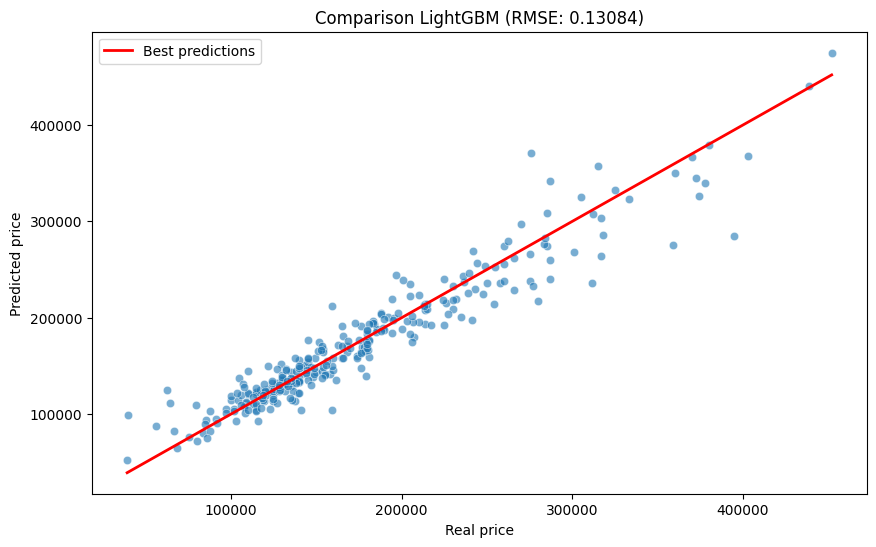

Avg loss (LightGBM): 9.00%


In [209]:
y_test_pred = random_search_lightgbm.predict(X_test)

y_test_real      = np.expm1(y_test)
y_test_pred_real = np.expm1(y_test_pred)

plt.figure(figsize=(10, 6))
sns.scatterplot(x=y_test_real, y=y_test_pred_real, alpha=0.6)
line_coords = [y_test_real.min(), y_test_real.max()]
plt.plot(line_coords, line_coords, color='red', lw=2, label='Best predictions')
plt.xlabel('Real price')
plt.ylabel('Predicted price')
plt.title(f'Comparison LightGBM (RMSE: {rmse_lgbm:.5f})')
plt.legend()
plt.show()

mape = mean_absolute_percentage_error(np.expm1(y_test), np.expm1(y_test_pred))
print(f'Avg loss (LightGBM): {mape*100:.2f}%')

### XGBoost

In [210]:
xgboost_pipeline = Pipeline([
    ('preprocessor', preprocessor),
    ('xgb', XGBRegressor(random_state=42, device=device, verbosity=0))
])

param_dist_xgboost = {
    'xgb__n_estimators':     [100, 300, 500, 700],
    'xgb__learning_rate':    [0.01, 0.05, 0.1, 0.15],
    'xgb__max_depth':        [3, 5, 7],
    'xgb__min_child_weight': [1, 3, 5],
    'xgb__subsample':        [0.6, 0.8, 1.0],
    'xgb__colsample_bytree': [0.5, 0.7, 1.0],
    'xgb__gamma':            [0, 0.1, 0.3],
    'xgb__reg_alpha':        [0, 1, 5],
    'xgb__reg_lambda':       [1, 3, 5],
}

random_search_xgboost = RandomizedSearchCV(
    xgboost_pipeline,
    param_distributions=param_dist_xgboost,
    n_iter=50,
    cv=skf.split(X_train, y_binned_train),
    scoring='neg_mean_squared_error',
    verbose=0,
    n_jobs=-1,
    random_state=42
)

random_search_xgboost.fit(X_train, y_train)

y_pred_xgb = random_search_xgboost.best_estimator_.predict(X_test)
rmse_xgb = np.sqrt(mean_squared_error(y_test, y_pred_xgb))
print(f'XGBoost Best Params: {random_search_xgboost.best_params_}')
print(f'XGBoost RMSE: {rmse_xgb:.5f}')


XGBoost Best Params: {'xgb__subsample': 0.6, 'xgb__reg_lambda': 1, 'xgb__reg_alpha': 0, 'xgb__n_estimators': 700, 'xgb__min_child_weight': 3, 'xgb__max_depth': 3, 'xgb__learning_rate': 0.01, 'xgb__gamma': 0, 'xgb__colsample_bytree': 0.5}
XGBoost RMSE: 0.12265


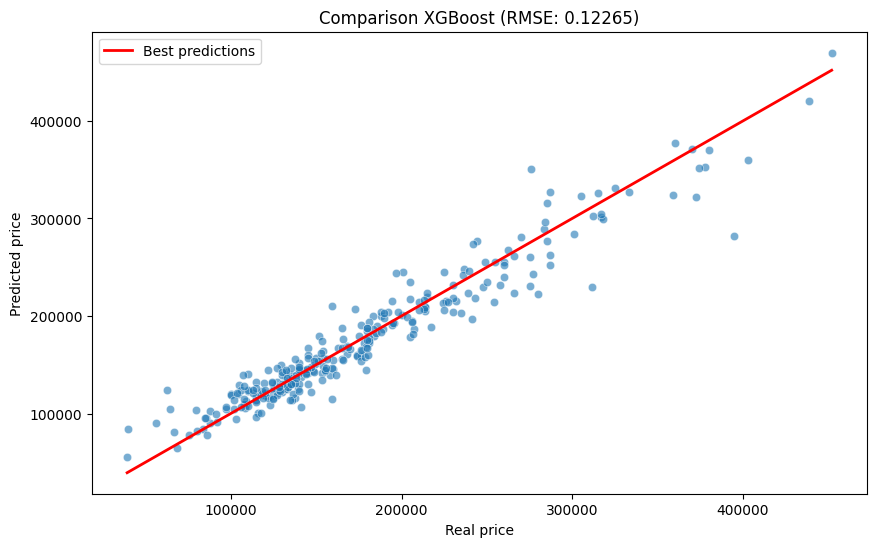

Avg loss (XGBoost): 8.57%


In [211]:
y_test_pred = random_search_xgboost.predict(X_test)

y_test_real      = np.expm1(y_test)
y_test_pred_real = np.expm1(y_test_pred)

plt.figure(figsize=(10, 6))
sns.scatterplot(x=y_test_real, y=y_test_pred_real, alpha=0.6)
line_coords = [y_test_real.min(), y_test_real.max()]
plt.plot(line_coords, line_coords, color='red', lw=2, label='Best predictions')
plt.xlabel('Real price')
plt.ylabel('Predicted price')
plt.title(f'Comparison XGBoost (RMSE: {rmse_xgb:.5f})')
plt.legend()
plt.show()

mape = mean_absolute_percentage_error(np.expm1(y_test), np.expm1(y_test_pred))
print(f'Avg loss (XGBoost): {mape*100:.2f}%')


### DNN + Embeddings (Tab-Transformer Pipeline)

In [212]:
from sklearn.preprocessing import OrdinalEncoder as EmbedOrdinal

all_cat_cols = cat_cols_none + cat_cols_mode

num_pipe_dnn = Pipeline([
    ('imputer', SimpleImputer(strategy='median')),
    ('scaler',  StandardScaler())
])
cat_pipe_dnn = Pipeline([
    ('imputer', SimpleImputer(strategy='most_frequent')),
    ('ordinal', EmbedOrdinal(handle_unknown='use_encoded_value', unknown_value=-1))
])

X_num_train = num_pipe_dnn.fit_transform(X_train[num_cols])
X_num_test  = num_pipe_dnn.transform(X_test[num_cols])

X_cat_train = cat_pipe_dnn.fit_transform(X_train[all_cat_cols]).astype(int) + 1
X_cat_test  = cat_pipe_dnn.transform(X_test[all_cat_cols]).astype(int) + 1

cat_sizes  = [int(X_cat_train[:, i].max()) + 1 for i in range(X_cat_train.shape[1])]
embed_dims = [max(2, min(50, s // 2)) for s in cat_sizes]

print(f'Numerical : {X_num_train.shape[1]} features')
print(f'Categorical: {X_cat_train.shape[1]} features  -> embed dim total: {sum(embed_dims)}')


Numerical : 42 features
Categorical: 43 features  -> embed dim total: 137


In [213]:
from torch.utils.data import Dataset, DataLoader

class AmesEmbedDataset(Dataset):
    def __init__(self, X_num, X_cat, y):
        self.X_num = torch.tensor(X_num, dtype=torch.float32)
        self.X_cat = torch.tensor(X_cat, dtype=torch.long)
        self.y     = torch.tensor(y,     dtype=torch.float32).view(-1, 1)
    def __len__(self):
        return len(self.y)
    def __getitem__(self, idx):
        return self.X_num[idx], self.X_cat[idx], self.y[idx]

ames_dataset    = AmesEmbedDataset(X_num_train, X_cat_train, y_train.values)
ames_dataloader = DataLoader(ames_dataset, batch_size=64, shuffle=True, drop_last=True)

val_dataset    = AmesEmbedDataset(X_num_test, X_cat_test, y_test.values)
val_dataloader = DataLoader(val_dataset,  batch_size=64, shuffle=False)

x_num, x_cat, y_b = next(iter(ames_dataloader))
print(f'Batch: num={x_num.shape}, cat={x_cat.shape}, y={y_b.shape}')


Batch: num=torch.Size([64, 42]), cat=torch.Size([64, 43]), y=torch.Size([64, 1])


In [ ]:
from dataclasses import dataclass

@dataclass
class DNNConfig:
    hidden_dim:    int   = 128
    num_heads:     int   = 4
    num_layers:    int   = 3
    mlp_ratio:     float = 2.0
    dropout:       float = 0.10
    batch_size:    int   = 64
    epochs:        int   = 300
    patience:      int   = 40
    lr:            float = 1e-3
    weight_decay:  float = 1e-4
    warmup_epochs: int   = 10
    grad_accum:    int   = 2
    grad_clip:     float = 1.0

cfg = DNNConfig()


class TransformerBlock(nn.Module):
    def __init__(self, dim, heads, mlp_ratio, dropout):
        super().__init__()
        self.norm1 = nn.LayerNorm(dim)
        self.attn  = nn.MultiheadAttention(dim, heads, dropout=dropout, batch_first=True)
        self.norm2 = nn.LayerNorm(dim)
        mlp_dim = int(dim * mlp_ratio)
        self.mlp = nn.Sequential(
            nn.Linear(dim, mlp_dim), nn.GELU(), nn.Dropout(dropout),
            nn.Linear(mlp_dim, dim), nn.Dropout(dropout),
        )

    def forward(self, x):
        normed      = self.norm1(x)
        attn_out, _ = self.attn(normed, normed, normed)
        x = x + attn_out
        x = x + self.mlp(self.norm2(x))
        return x


class AmesTabTransformer(nn.Module):
    def __init__(self, num_features, cat_sizes, cfg):
        super().__init__()
        D = cfg.hidden_dim
        self.cat_embeds  = nn.ModuleList([nn.Embedding(sz, D) for sz in cat_sizes])
        self.num_projs   = nn.ModuleList([nn.Linear(1, D)     for _ in range(num_features)])
        self.cls_token   = nn.Parameter(torch.zeros(1, 1, D))
        self.transformer = nn.Sequential(*[
            TransformerBlock(D, cfg.num_heads, cfg.mlp_ratio, cfg.dropout)
            for _ in range(cfg.num_layers)
        ])
        self.norm = nn.LayerNorm(D)
        self.head = nn.Sequential(
            nn.Linear(D, D // 2), nn.GELU(), nn.Dropout(cfg.dropout),
            nn.Linear(D // 2, 1),
        )
        self._init_weights()

    def _init_weights(self):
        for m in self.modules():
            if isinstance(m, nn.Linear):
                nn.init.xavier_uniform_(m.weight)
                if m.bias is not None:
                    nn.init.zeros_(m.bias)
        nn.init.trunc_normal_(self.cls_token, std=0.02)

    def forward(self, x_num, x_cat):
        B = x_num.size(0)
        num_tokens = [proj(x_num[:, i:i+1]).unsqueeze(1) for i, proj in enumerate(self.num_projs)]
        cat_tokens = [emb(x_cat[:, i]).unsqueeze(1)      for i, emb  in enumerate(self.cat_embeds)]
        cls    = self.cls_token.expand(B, -1, -1)
        tokens = torch.cat([cls] + num_tokens + cat_tokens, dim=1)
        tokens = self.transformer(tokens)
        tokens = self.norm(tokens)
        return self.head(tokens[:, 0])


_probe = AmesTabTransformer(X_num_train.shape[1], cat_sizes, cfg)
total_params = sum(p.numel() for p in _probe.parameters())
print(f'Config : hidden_dim={cfg.hidden_dim}, heads={cfg.num_heads}, layers={cfg.num_layers}')
print(f'Tokens : {X_num_train.shape[1]} num + {len(cat_sizes)} cat + 1 CLS = {X_num_train.shape[1]+len(cat_sizes)+1}')
print(f'Params : {total_params:,}')


In [ ]:
from torch.optim.lr_scheduler import LinearLR, CosineAnnealingLR, SequentialLR

nn_model  = AmesTabTransformer(X_num_train.shape[1], cat_sizes, cfg).to(device)
criterion = nn.MSELoss()
optimizer = optim.AdamW(nn_model.parameters(), lr=cfg.lr, weight_decay=cfg.weight_decay)

warmup_sched = LinearLR(optimizer, start_factor=1e-3, end_factor=1.0, total_iters=cfg.warmup_epochs)
cosine_sched = CosineAnnealingLR(optimizer, T_max=cfg.epochs - cfg.warmup_epochs, eta_min=1e-5)
scheduler    = SequentialLR(optimizer, schedulers=[warmup_sched, cosine_sched], milestones=[cfg.warmup_epochs])

use_amp = (device == 'cuda')
scaler  = torch.cuda.amp.GradScaler(enabled=use_amp)

print(f'Device : {device}  |  AMP : {use_amp}')
print(f'Warmup : {cfg.warmup_epochs} epochs  ->  CosineAnnealing : {cfg.epochs - cfg.warmup_epochs} epochs')
print(f'Grad accum : {cfg.grad_accum}  |  Effective batch : {cfg.batch_size * cfg.grad_accum}')


In [ ]:
train_losses, val_losses = [], []
best_val_loss, no_improve, best_weights = float('inf'), 0, None

for epoch in range(cfg.epochs):
    nn_model.train()
    train_loss = 0.0
    optimizer.zero_grad()

    for step, (x_num, x_cat, labels) in enumerate(ames_dataloader):
        x_num, x_cat, labels = x_num.to(device), x_cat.to(device), labels.to(device)

        with torch.autocast(device_type=device, dtype=torch.float16, enabled=use_amp):
            loss = criterion(nn_model(x_num, x_cat), labels) / cfg.grad_accum

        scaler.scale(loss).backward()
        train_loss += loss.item() * cfg.grad_accum * x_num.size(0)

        if (step + 1) % cfg.grad_accum == 0 or (step + 1) == len(ames_dataloader):
            scaler.unscale_(optimizer)
            nn.utils.clip_grad_norm_(nn_model.parameters(), cfg.grad_clip)
            scaler.step(optimizer)
            scaler.update()
            optimizer.zero_grad()

    nn_model.eval()
    val_loss = 0.0
    with torch.no_grad():
        for x_num, x_cat, labels in val_dataloader:
            x_num, x_cat, labels = x_num.to(device), x_cat.to(device), labels.to(device)
            val_loss += criterion(nn_model(x_num, x_cat), labels).item() * x_num.size(0)

    scheduler.step()
    ep_train = train_loss / len(ames_dataloader.dataset)
    ep_val   = val_loss   / len(val_dataloader.dataset)
    train_losses.append(ep_train)
    val_losses.append(ep_val)

    if ep_val < best_val_loss:
        best_val_loss = ep_val
        no_improve    = 0
        best_weights  = {k: v.clone() for k, v in nn_model.state_dict().items()}
        torch.save({'epoch': epoch + 1, 'model_state': best_weights, 'val_loss': best_val_loss}, 'dnn_checkpoint.pt')
    else:
        no_improve += 1

    if (epoch + 1) % 20 == 0:
        print(f'Epoch {epoch+1:3d}/{cfg.epochs} | train={ep_train:.5f} | val={ep_val:.5f} | lr={scheduler.get_last_lr()[0]:.2e} | patience={no_improve}/{cfg.patience}')

    if no_improve >= cfg.patience:
        print(f'Early stopping at epoch {epoch + 1}')
        break

nn_model.load_state_dict(best_weights)
print(f'Best val MSE: {best_val_loss:.5f}')


In [ ]:
plt.figure(figsize=(12, 6))
plt.plot(train_losses, label='Train MSE')
plt.plot(val_losses,   label='Val MSE')
best_ep = int(np.argmin(val_losses))
plt.axvline(best_ep, color='red',    linestyle='--', label=f'Best epoch {best_ep + 1}')
plt.axvline(cfg.warmup_epochs, color='orange', linestyle=':', label=f'Warmup end ({cfg.warmup_epochs})')
plt.title('Tab-Transformer — Training Curve')
plt.xlabel('Epoch')
plt.ylabel('MSE (log-space)')
plt.legend()
plt.grid(True, linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()
print(f'Stopped at epoch {len(train_losses)}, best epoch {best_ep + 1}')


In [ ]:
x_num_test_t = torch.tensor(X_num_test, dtype=torch.float32).to(device)
x_cat_test_t = torch.tensor(X_cat_test, dtype=torch.long).to(device)

nn_model.eval()
with torch.no_grad():
    y_test_pred = nn_model(x_num_test_t, x_cat_test_t).cpu().numpy().flatten()

rmse_dnn = np.sqrt(mean_squared_error(y_test, y_test_pred))

y_test_real      = np.expm1(y_test)
y_test_pred_real = np.expm1(y_test_pred)

plt.figure(figsize=(10, 6))
sns.scatterplot(x=y_test_real, y=y_test_pred_real, alpha=0.6)
line_coords = [y_test_real.min(), y_test_real.max()]
plt.plot(line_coords, line_coords, color='red', lw=2, label='Perfect prediction')
plt.xlabel('Real price')
plt.ylabel('Predicted price')
plt.title(f'Tab-Transformer DNN (RMSE: {rmse_dnn:.5f})')
plt.legend()
plt.show()

mape = mean_absolute_percentage_error(y_test_real, y_test_pred_real)
print(f'Avg loss (DNN+Embeddings): {mape*100:.2f}%')


### Stacking

In [222]:
estimators = [
    ('ridge',    grid_search_ridge.best_estimator_),
    ('svr',      grid_search_svr.best_estimator_),
    ('catboost', random_search_cat.best_estimator_),
    ('xgboost',  random_search_xgboost.best_estimator_),
    ('lightgbm', random_search_lightgbm.best_estimator_),
]

stacking_model = StackingRegressor(
    estimators=estimators,
    final_estimator=Ridge(),
    cv=5,
    n_jobs=-1
)
stacking_model.fit(X_train, y_train)

y_test_pred = stacking_model.predict(X_test)
mape = mean_absolute_percentage_error(np.expm1(y_test), np.expm1(y_test_pred))
print(f'Stacking MAPE: {mape*100:.2f}%')

Stacking MAPE: 7.75%


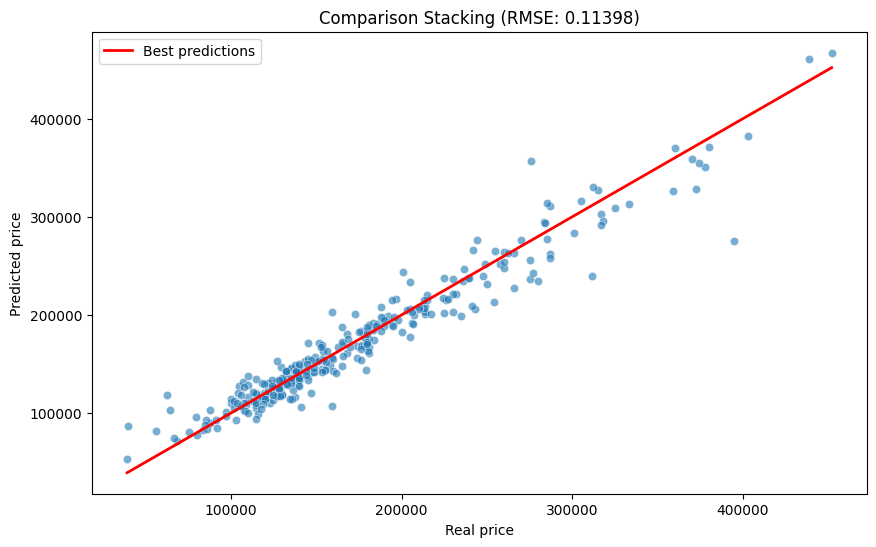

Avg loss (Stacking): 7.75%


In [223]:
y_test_pred    = stacking_model.predict(X_test)
rmse_stacking  = np.sqrt(mean_squared_error(y_test, y_test_pred))

y_test_real      = np.expm1(y_test)
y_test_pred_real = np.expm1(y_test_pred)

plt.figure(figsize=(10, 6))
sns.scatterplot(x=y_test_real, y=y_test_pred_real, alpha=0.6)
line_coords = [y_test_real.min(), y_test_real.max()]
plt.plot(line_coords, line_coords, color='red', lw=2, label='Best predictions')
plt.xlabel('Real price')
plt.ylabel('Predicted price')
plt.title(f'Comparison Stacking (RMSE: {rmse_stacking:.5f})')
plt.legend()
plt.show()

mape = mean_absolute_percentage_error(y_test_real, y_test_pred_real)
print(f'Avg loss (Stacking): {mape*100:.2f}%')

### Simple Averaging

In [224]:
top_models_preds = np.column_stack([
    grid_search_ridge.best_estimator_.predict(X_test),
    grid_search_svr.best_estimator_.predict(X_test),
    random_search_cat.best_estimator_.predict(X_test),
    random_search_xgboost.best_estimator_.predict(X_test),
    random_search_lightgbm.best_estimator_.predict(X_test),
])
y_pred_avg = top_models_preds.mean(axis=1)
rmse_avg   = np.sqrt(mean_squared_error(y_test, y_pred_avg))

print(f'Best RMSE (SimpleAverage): {rmse_avg:.5f}')


Best RMSE (SimpleAverage): 0.11723


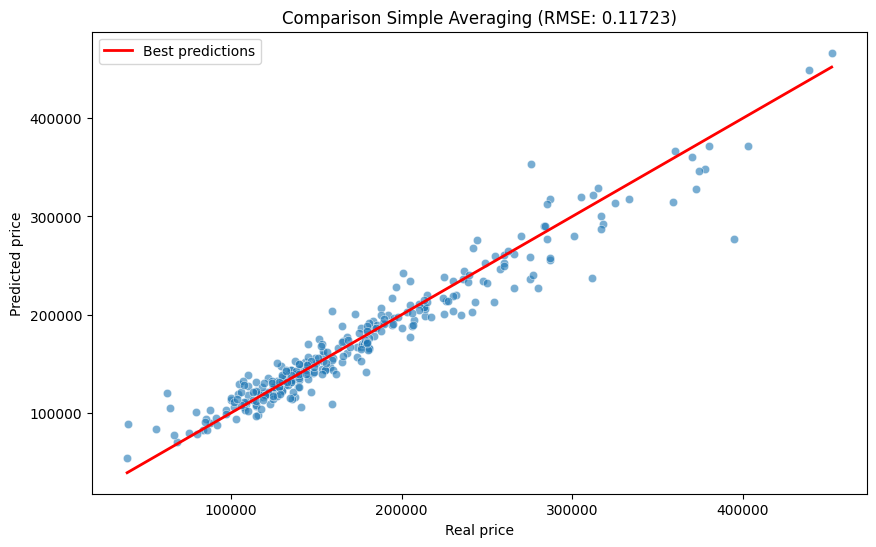

Avg loss (SimpleAverage): 7.94%


In [225]:
y_test_real     = np.expm1(y_test)
y_pred_avg_real = np.expm1(y_pred_avg)

plt.figure(figsize=(10, 6))
sns.scatterplot(x=y_test_real, y=y_pred_avg_real, alpha=0.6)
line_coords = [y_test_real.min(), y_test_real.max()]
plt.plot(line_coords, line_coords, color='red', lw=2, label='Best predictions')
plt.xlabel('Real price')
plt.ylabel('Predicted price')
plt.title(f'Comparison Simple Averaging (RMSE: {rmse_avg:.5f})')
plt.legend()
plt.show()

mape_avg = mean_absolute_percentage_error(y_test_real, y_pred_avg_real)
print(f'Avg loss (SimpleAverage): {mape_avg*100:.2f}%')


### Vouting

In [226]:
voting_model = VotingRegressor(
    estimators=[
        ('ridge',    grid_search_ridge.best_estimator_),
        ('svr',      grid_search_svr.best_estimator_),
        ('catboost', random_search_cat.best_estimator_),
        ('xgboost',  random_search_xgboost.best_estimator_),
        ('lightgbm', random_search_lightgbm.best_estimator_),
    ],
    n_jobs=-1
)
voting_model.fit(X_train, y_train)

y_test_pred = voting_model.predict(X_test)
mape = mean_absolute_percentage_error(np.expm1(y_test), np.expm1(y_test_pred))
print(f'Voting MAPE: {mape*100:.2f}%')

Voting MAPE: 7.94%


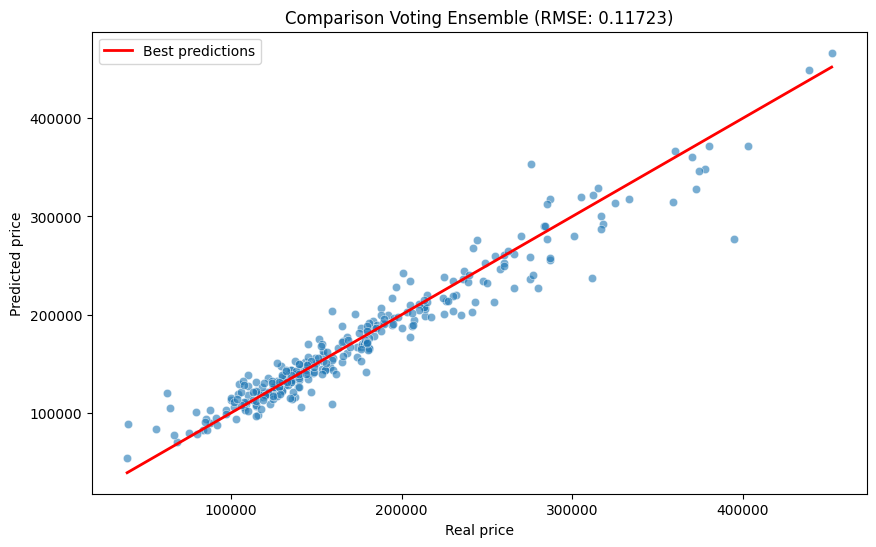

Avg loss (Voting): 7.94%


In [227]:
y_test_pred  = voting_model.predict(X_test)
rmse_voting  = np.sqrt(mean_squared_error(y_test, y_test_pred))

y_test_real      = np.expm1(y_test)
y_test_pred_real = np.expm1(y_test_pred)

plt.figure(figsize=(10, 6))
sns.scatterplot(x=y_test_real, y=y_test_pred_real, alpha=0.6)
line_coords = [y_test_real.min(), y_test_real.max()]
plt.plot(line_coords, line_coords, color='red', lw=2, label='Best predictions')
plt.xlabel('Real price')
plt.ylabel('Predicted price')
plt.title(f'Comparison Voting Ensemble (RMSE: {rmse_voting:.5f})')
plt.legend()
plt.show()

mape = mean_absolute_percentage_error(y_test_real, y_test_pred_real)
print(f'Avg loss (Voting): {mape*100:.2f}%')

### Result comparison

In [228]:
models_dict = {
    'LinearRegression': lr_pipeline,
    'Lasso':            grid_search_lasso.best_estimator_,
    'Ridge':            grid_search_ridge.best_estimator_,
    'ElasticNet':       grid_search_elastic_net.best_estimator_,
    'KNN':              grid_search_knn.best_estimator_,
    'SVR':              grid_search_svr.best_estimator_,
    'DecisionTree':     random_search_dt.best_estimator_,
    'RandomForest':     random_search_rt.best_estimator_,
    'CatBoost':         random_search_cat.best_estimator_,
    'LightGBM':         random_search_lightgbm.best_estimator_,
    'XGBoost':          random_search_xgboost.best_estimator_,
    'DNN':              nn_model,
    'SimpleAverage':    None,
    'Stacking':         stacking_model,
    'VotingEnsemble':   voting_model,
}

results_list = []

for name, model in models_dict.items():
    if name == 'DNN':
        model.eval()
        with torch.no_grad():
            y_log_pred = model(
                torch.tensor(X_num_test, dtype=torch.float32).to(device),
                torch.tensor(X_cat_test, dtype=torch.long).to(device)
            ).cpu().numpy().flatten()
    elif name == 'SimpleAverage':
        top_preds = np.column_stack([
            grid_search_ridge.best_estimator_.predict(X_test),
            grid_search_svr.best_estimator_.predict(X_test),
            random_search_cat.best_estimator_.predict(X_test),
            random_search_xgboost.best_estimator_.predict(X_test),
            random_search_lightgbm.best_estimator_.predict(X_test),
        ])
        y_log_pred = top_preds.mean(axis=1)
    else:
        y_log_pred = model.predict(X_test)

    y_real_pred = np.expm1(y_log_pred)
    y_real_true = np.expm1(y_test)

    rmse_log = np.sqrt(mean_squared_error(y_test, y_log_pred))
    mape_pct = mean_absolute_percentage_error(y_real_true, y_real_pred) * 100

    results_list.append({
        'Model': name,
        'RMSE (Log)': rmse_log,
        'MAPE (%)': mape_pct
    })

df_results = pd.DataFrame(results_list).sort_values(by='MAPE (%)')
display(df_results)


,Model,RMSE (Log),MAPE (%)
13,Stacking,0.113984,7.746264
5,SVR,0.117108,7.915833
12,SimpleAverage,0.117231,7.935783
14,VotingEnsemble,0.117231,7.935783
8,CatBoost,0.118971,8.198264
10,XGBoost,0.122654,8.570905
2,Ridge,0.122109,8.690230
3,ElasticNet,0.122972,8.703638
9,LightGBM,0.130837,9.002340
0,LinearRegression,0.130276,9.132970


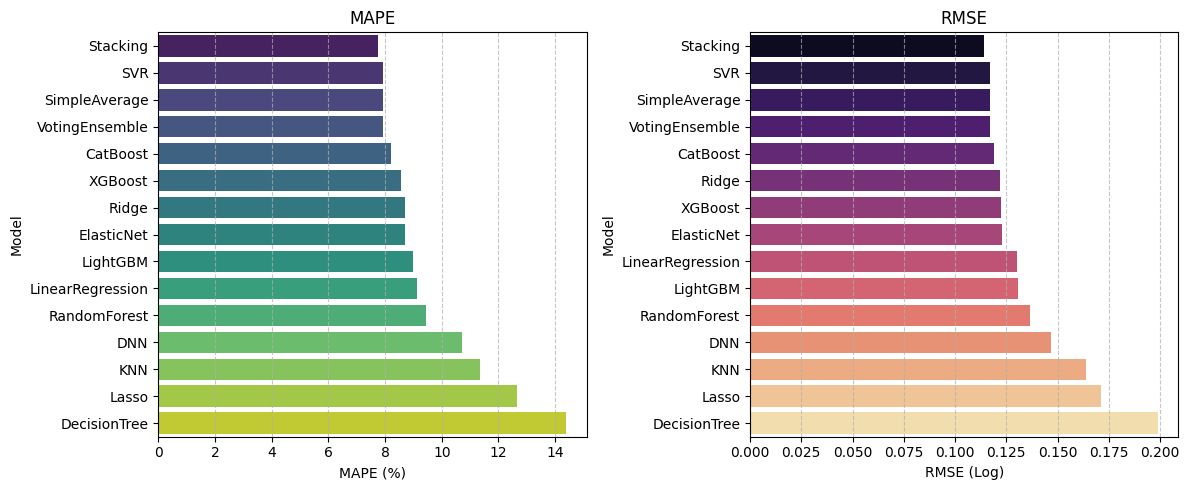

In [229]:
plt.figure(figsize=(12, 5))

plt.subplot(1, 2, 1)
sns.barplot(x='MAPE (%)', y='Model', data=df_results, hue='Model', palette='viridis', legend=False)
plt.title('MAPE')
plt.grid(axis='x', linestyle='--', alpha=0.7)

plt.subplot(1, 2, 2)
df_rmse = df_results.sort_values('RMSE (Log)')
sns.barplot(x='RMSE (Log)', y='Model', data=df_rmse, hue='Model', palette='magma', legend=False)
plt.title('RMSE')
plt.grid(axis='x', linestyle='--', alpha=0.7)

plt.tight_layout()
plt.show()